# Laboratorio: la señal de temperatura — guía del docente

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/docente/lab-senal-temperatura.ipynb)

> Versión con las soluciones completas. La versión para estudiantes, con esqueletos en lugar de las soluciones, es `notebooks/lab-senal-temperatura.ipynb`.

Este laboratorio cierra el problema conductor de la Parte II: **la temperatura del aire, medida cada hora durante tres años en Aeroparque**. En el texto vimos las herramientas (series de Fourier, transformada de Fourier, DFT, filtrado y compresión) y los notebooks `06-series`, `07-transformada-DFT` y `08-aplicaciones` las aplican a esta serie y muestran los resultados principales. Acá **las usás vos**, con más cuidado, sobre datos reales, y aparecen todas las cosas que con una señal sintética no aparecen: una media que no es cero, una tendencia (¿o no?), picos que no caen exactamente en la grilla, ruido que no es blanco, fuga espectral.

Las cinco preguntas del problema conductor (al comienzo de la Parte II de las notas) son el hilo del laboratorio, y la parte que se evalúa es una respuesta escrita a cada una:

1. ¿Qué frecuencias contiene la serie? ¿Con qué amplitud y fase contribuye cada una? ¿Cuánto de la variabilidad total explican el ciclo diario y el anual?
2. ¿Cómo separar la parte "regular" (los ciclos) de la parte irregular, y qué queda cuando se lo hace?
3. Si en lugar de una medición por hora tuviéramos una por día, o una por semana, ¿qué información se pierde y qué información *se falsea*?
4. ¿Cuántos números hacen falta para reconstruir la señal con un error dado? ¿Se puede comprimir?
5. Las herramientas que sirven para esta señal, ¿sirven igual para un audio, un electrocardiograma o una imagen?

**Qué vamos a hacer.** (1) Cargar los datos, mirarlos y *elegir el tramo* sobre el que se calcula la DFT; (2) calcular el espectro de potencia, en ciclos por día y en escala logarítmica, e identificar los picos y la forma del piso; (3) medir amplitud y fase de los ciclos anual y diario, de dos maneras (con la DFT y por mínimos cuadrados) y ver cómo cambia el ciclo diario con la estación; (4) calcular la varianza explicada con la identidad de Parseval; (5) entender la fuga espectral y qué hace una ventana de Hann; (6) submuestrear la serie y ver el aliasing en datos reales; (7) filtrar en frecuencia, estudiar el residuo y compararlo con los promedios móviles (que también son filtros: ¿cuál es su respuesta en frecuencia?); (8) comprimir por coeficientes de mayor módulo; (9) hacer el espectrograma de la temperatura y de una cuerda de guitarra, y discutir el compromiso tiempo–frecuencia.

**Lo que las notas no explican y este notebook sí.** Cómo pasar de la DFT a unidades físicas (ciclos por día, °C, horas del día, fechas); cómo elegir el tramo de datos y por qué importa que sea múltiplo de los períodos; qué es el periodograma y por qué se mira en escala logarítmica; qué es la fuga espectral y las ventanas; cómo se estima una amplitud y una fase con la DFT y por mínimos cuadrados con frecuencia fija (y cuándo dan distinto); la respuesta en frecuencia de un promedio móvil; y el espectrograma (STFT). El texto de cada sección es la única presentación que van a tener de esos temas: leanlo, no solo las consignas.

**Herramientas disponibles.** `imc.espectro` (`dft`, `amplitudes`, `periodograma`, `welch`, `filtrar`, `espectrograma`; leé los docstrings: las convenciones de normalización están ahí), `imc.datos.obtener` (los datos), `imc.estilo` (colores y figuras), `numpy.fft`, `scipy.io.wavfile` (audio) y `pandas` (fechas). No vamos a reconstruir lo que ya hacen los notebooks del texto (`07-transformada-DFT`: espectro de amplitudes y aliasing con la serie de 2023; `08-aplicaciones`: filtro de picos, residuo, compresión de la serie y de la imagen): allí están los resultados de referencia, y conviene tenerlos a mano para comparar. La diferencia es que acá se trata de que los produzcas vos, entiendas por qué dan lo que dan y los interpretes.

**Cómo se evalúa.** Como siempre: la sección final de **interpretación escrita**. Cada tarea dice qué se espera y trae una celda de verificación; si un `assert` falla, el mensaje te dice qué revisar. Las celdas de verificación no reemplazan la interpretación: un número correcto sin explicación no alcanza. Tiempo estimado: **dos sesiones de 3 a 4 h**: las Tareas 1 a 6 (la primera mitad: espectro, amplitud y fase, varianza, ventanas, aliasing) y las Tareas 7 a 9 (filtrado, compresión, espectrograma).

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from imc import estilo, datos
from imc.estilo import COLORES
import pandas as pd
import matplotlib.dates as mdates
from scipy.io import wavfile
from imc import espectro
from imc.estilo import CICLO
estilo.activar()

## 1. Los datos, las unidades y la elección del tramo

### Los datos

`temperatura_horaria.csv` (ver `datos/README.md`) tiene la temperatura del aire a 2 m, en °C, cada hora, del 1/1/2021 al 31/12/2023: $3 \times 365 \times 24 = 26\,280$ valores, sin huecos. Ojo con dos cosas. Son datos de **reanálisis** (un modelo numérico que asimila observaciones, ERA5), así que son más suaves y regulares que los de un termómetro real: sirven perfectamente para lo que hacemos, pero no los tomes por una medición directa. Y la hora es **local sin cambio de horario** (en Argentina no lo hay desde 2009), de modo que "a las 15:00" significa lo mismo en enero que en julio y el ciclo diario no se corre artificialmente.

### Unidades: de la DFT a ciclos por día

La DFT de $N$ muestras $x_j = x(t_j)$, $t_j = j\,\Delta t$, es $\hat x[k] = \sum_{j=0}^{N-1} x_j\, e^{-2\pi i jk/N}$. El coeficiente $k$ corresponde a la frecuencia

$$\xi_k = \frac{k}{T} = \frac{k}{N\,\Delta t}, \qquad T = N\,\Delta t \ \text{(duración del tramo)},$$

en las unidades de $1/\Delta t$. **Nosotros medimos el tiempo en días**: $\Delta t = 1/24$ día, y $\xi$ queda en **ciclos por día**. Si $T$ son 365 días, $\xi_k = k/365$ ciclos por día $= k$ ciclos por año: el ciclo anual es $k = 1$; el diario, $\xi = 1$ ciclo/día, es $k = 365$; el de 12 horas, $k = 730$. Tres cosas para tener siempre presentes:

* la **resolución en frecuencia** es $\Delta\xi = 1/T$: dos frecuencias más cercanas que eso no se distinguen;
* la frecuencia más alta representable es la de **Nyquist**, $\xi_{\max} = 1/(2\Delta t) = 12$ ciclos/día (período de 2 horas);
* para una señal real, $\hat x[N-k] = \overline{\hat x[k]}$: alcanza con la mitad $k = 0, \dots, N/2$ (`np.fft.rfft`, que es lo que usa `imc.espectro`).

### Media, tendencia y elección del tramo

**La media.** El coeficiente $\hat x[0] = \sum_j x_j = N\bar x$ es la media (por $N$). Con una temperatura de unos 18 °C y fluctuaciones de unos 6 °C, la media aporta el 90 % de $\sum x_j^2$: si no se la resta, el espectro queda dominado por un pico en $k = 0$ que no dice nada sobre las oscilaciones. `espectro.periodograma` la resta por defecto.

**La tendencia.** Una serie que sube o baja lentamente no es periódica, y la DFT (que supone que la señal se repite con período $T$) ve un *salto* entre el último y el primer valor. Ese salto reparte energía en todas las frecuencias (la fuga de la Sección 5). En series largas se resta una tendencia lineal antes de la DFT; en la nuestra hay que preguntarse antes si hay tendencia: con tres años, ¿una pendiente de unas décimas de grado por año es una tendencia climática o la variación de un año a otro? (Mirá cuánto varía la media anual.)

**El tramo.** La DFT trabaja con *todo* el vector que se le da. Si $T$ es un múltiplo de un período, la frecuencia correspondiente cae exactamente en un $k$ entero y aparece en un solo coeficiente; si no, se reparte entre coeficientes vecinos (fuga). Hay dos elecciones naturales:

* **Un año exacto (2023):** $N = 8760$, $T = 365$ días. El ciclo anual es $k = 1$ y el diario $k = 365$, ambos exactamente en la grilla. La resolución es $1/365$ ciclos/día.
* **Los tres años:** $N = 26\,280$, $T = 1095$ días. La resolución mejora a $1/1095$ (el anual es $k = 3$, el diario $k = 1095$), pero el ciclo anual **no es el mismo** cada año (el 2022 fue más frío que el 2023) y ese ciclo "casi periódico" se ensancha en un pico más ancho y más bajo.

Trabajamos con 2023, que es la elección de las notas y la de los notebooks del texto. Al final de la tarea van a poder decir por qué.

### Tarea 1: Cargar, graficar y elegir el tramo

La celda ya carga el archivo con `pandas` (columnas `fecha_hora`, `temp`). Completá:

1. Una figura de dos paneles: arriba la serie completa (2021–2023), abajo un zoom de dos semanas (por ejemplo del 1 al 14 de enero de 2023). Ejes con nombre y unidades.
2. La media y la varianza (`T.var()`, sin corrección: la de la identidad de Parseval) de cada año y de toda la serie, y la pendiente de la recta de mínimos cuadrados de toda la serie en °C por año (`np.polyfit` contra `anios`, el tiempo en años). ¿Es una tendencia?
3. Las variables del tramo de 2023 que vamos a usar en todo el resto: `T` (los 8760 valores, `float`), `fecha` (las fechas correspondientes, una `Series` de `pandas`), `N`, `dt` (en días) y `t` (tiempos en días desde el 1/1/2023 a las 00:00).

**Qué se espera.** Una serie con un ciclo anual bien claro (más cálida en el verano austral, es decir, en enero–febrero) y, en el zoom, un ciclo diario con máximos a media tarde, montado sobre variaciones irregulares de varios días (frentes). Medias anuales del orden de 17–18 °C, varianzas de 36–40 °C² y una pendiente de unas décimas de grado por año, del mismo tamaño que la diferencia entre años: no hay evidencia de tendencia con tres años. Anotá en una línea por qué elegís 2023 y no los tres años.

(26280, 2) 2021-01-01 00:00:00 -> 2023-12-31 23:00:00
2021: media 17.59 °C, varianza 35.83 °C²
2022: media 17.15 °C, varianza 38.90 °C²
2023: media 18.24 °C, varianza 39.95 °C²
toda la serie: media 17.66 °C, varianza 38.43 °C²
pendiente lineal de la serie de 3 años: -0.13 °C por año (las medias anuales difieren hasta 1.10 °C)


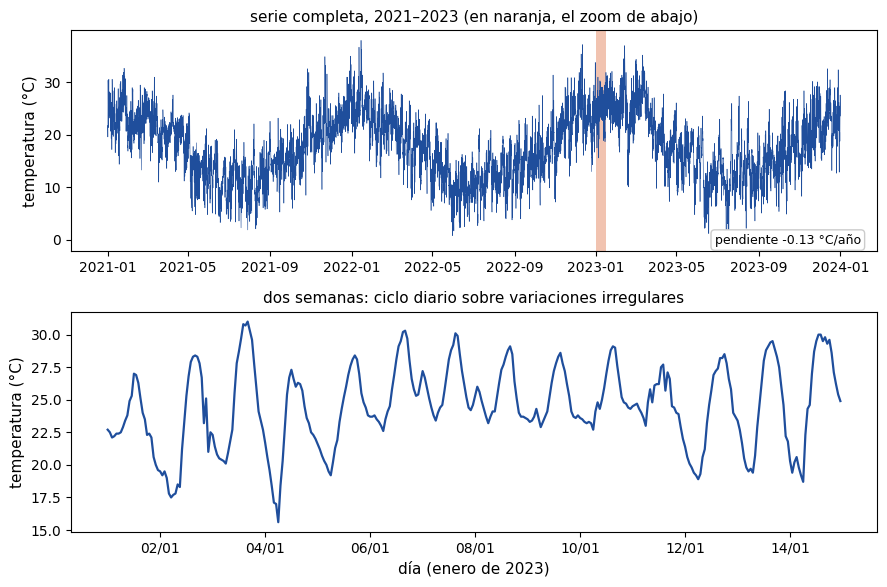

In [2]:
ruta = datos.obtener("temperatura_horaria.csv")
df = pd.read_csv(ruta, parse_dates=["fecha_hora"])
print(df.shape, df.fecha_hora.iloc[0], "->", df.fecha_hora.iloc[-1])

anio = df.fecha_hora.dt.year
for a in (2021, 2022, 2023):
    x = df.temp[anio == a].values
    print(f"{a}: media {x.mean():.2f} °C, varianza {x.var():.2f} °C²")
print(f"toda la serie: media {df.temp.mean():.2f} °C, varianza {df.temp.var(ddof=0):.2f} °C²")
anios = np.arange(len(df)) / 24 / 365
pendiente = np.polyfit(anios, df.temp, 1)[0]
print(f"pendiente lineal de la serie de 3 años: {pendiente:+.2f} °C por año "
      f"(las medias anuales difieren hasta {df.temp[anio == 2023].mean() - df.temp[anio == 2022].mean():.2f} °C)")

d23 = df[anio == 2023].reset_index(drop=True)
T = d23.temp.values
fecha = d23.fecha_hora
N = len(T)
dt = 1 / 24                       # días
t = np.arange(N) * dt             # días desde el 1/1/2023 00:00

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
ax1.plot(df.fecha_hora, df.temp, lw=0.4, color=COLORES["dato"])
ax1.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-01-15"), color=COLORES["modelo"], alpha=0.35, lw=0)
ax1.set_ylabel("temperatura (°C)"); ax1.set_title("serie completa, 2021–2023 (en naranja, el zoom de abajo)")
dos = (fecha >= "2023-01-01") & (fecha < "2023-01-15")
ax2.plot(fecha[dos], T[dos], color=COLORES["dato"])
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2)); ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax2.set_ylabel("temperatura (°C)"); ax2.set_xlabel("día (enero de 2023)")
ax2.set_title("dos semanas: ciclo diario sobre variaciones irregulares")
estilo.parametros(ax1, f"pendiente {pendiente:+.2f} °C/año", loc="lower right")
fig.tight_layout()

In [3]:
# Verificación
assert N == 8760 and abs(dt - 1 / 24) < 1e-12 and t.shape == (N,), "T, N, dt, t: el tramo debe ser 2023 (8760 horas, dt en días)"
assert fecha.iloc[0] == pd.Timestamp("2023-01-01 00:00") and fecha.iloc[-1] == pd.Timestamp("2023-12-31 23:00"), "fecha mal cortada"
assert abs(T.mean() - 18.24) < 0.01 and abs(T.var() - 39.95) < 0.05, "media y varianza de 2023: ~18.24 °C y ~39.95 °C²"
assert abs(pendiente) < 0.5, "la pendiente debe ser de décimas de °C por año (¿la calculaste contra el tiempo en años?)"
print(f"media 2023 = {T.mean():.2f} °C, varianza = {T.var():.2f} °C² (desvío {T.std():.2f} °C), pendiente {pendiente:+.2f} °C/año: OK")

media 2023 = 18.24 °C, varianza = 39.95 °C² (desvío 6.32 °C), pendiente -0.13 °C/año: OK


**Para el docente (Tarea 1).** Medias: 17.59, 17.15 y 18.24 °C (2021, 2022, 2023); varianzas 35.8, 38.9 y 39.95 °C²; pendiente de la serie completa $-0.13$ °C/año: negativa, y menor que la diferencia de 1.1 °C entre 2022 y 2023, así que no hay tendencia que restar. Con los tres años, la DFT (`amplitudes`) da $A = 6.94$ °C para el anual ($k = 3$) y $2.69$ para el diario, casi lo mismo, pero el máximo anual cae el 16 de enero y no el 25: **un solo año no determina la fase del ciclo anual con precisión de días** (buen tema de discusión: ¿el "máximo del ciclo anual" es una propiedad del clima o de ese año?). Errores típicos: `df.temp.var()` (con $N-1$: la diferencia es despreciable acá pero rompe la identidad de Parseval al cuarto decimal), medir `dt` en horas (y después leer $\xi$ en ciclos por hora), pasar a `T` la serie completa. Tiempo: 20 minutos.

## 2. El espectro de potencia (periodograma)

### Qué se grafica

Para $x$ real de $N$ muestras con la media restada, el **espectro de potencia** (o **periodograma**) es

$$P[k] = \frac{|\hat x[k]|^2}{N}, \qquad \xi_k = \frac{k}{N\,\Delta t}.$$

Es el que calcula `espectro.periodograma(x, dt)` (con la normalización que hace que valga la identidad de Plancherel–Parseval discreta $\sum_{k=0}^{N-1} P[k] = \sum_j x_j^2$; en la mitad $0 < k < N/2$ que se devuelve cada valor cuenta dos veces, por $\pm k$). $P[k]$ mide *cuánta energía de la señal hay en la frecuencia $\xi_k$*; un coseno de amplitud $A$ y frecuencia $\xi_k$ exactamente en la grilla produce $P[k] = A^2 N/4$: la altura de un pico depende de $N$ y de $A^2$, no es una "densidad" que se pueda comparar entre tramos de distinta longitud sin dividir por algo (Sección 5).

### Por qué escala logarítmica

Los picos del ciclo anual y del diario son cuatro o cinco órdenes de magnitud más altos que el "piso" de las fluctuaciones irregulares. En escala lineal solo se ve un par de palitos y el resto es una línea sobre el cero; con `semilogy` (potencia en log) se ven a la vez los picos, sus armónicos y la forma del piso, y con `loglog` (frecuencia también en log) una **ley de potencias** $P \propto \xi^{-\alpha}$ se ve como una recta de pendiente $-\alpha$. Es la forma estándar de mirar espectros de señales naturales.

### Qué esperar

* **Picos** en el ciclo anual ($\xi = 1/365$), en el diario ($\xi = 1$) y en sus armónicos: los múltiplos enteros de $1/365$ (ciclos del año que no son sinusoidales) y de $1$ ciclo/día (el ciclo diario no es un coseno puro: sube más despacio de lo que baja, y eso genera armónicos de 12 h, 8 h, 6 h, ...). Un armónico *existe* si sobresale del piso vecino; para decidirlo, compará $P[k]$ con la mediana de $P$ en los $\pm 20$ coeficientes que lo rodean (el "realce"). Ojo: no todo máximo local del periodograma es un pico genuino. El periodograma de una señal aleatoria es muy irregular (cada $P[k]$ fluctúa alrededor de su valor medio con una dispersión del orden del propio valor) y por puro azar aparecen máximos por todos lados, sobre todo donde el piso es alto, a bajas frecuencias. Un pico *real* sobresale del piso vecino por un factor grande, no por un factor 2 o 3.
* **Piso** que baja con la frecuencia: las fluctuaciones lentas (semanas) tienen mucha más energía que las rápidas (horas). Un espectro que decae como una ley de potencias se llama, por analogía con la luz, "ruido rojo"; uno plano, "ruido blanco". ¿De qué tipo es el de la temperatura? Se mide ajustando una recta a $\log P$ contra $\log \xi$ en un rango sin picos.

### Tarea 2: Espectro de potencia de 2023

1. Calculá `xi, P = espectro.periodograma(T, dt)` (`xi` sale en **ciclos por día** porque `dt` está en días). Verificá la resolución y la frecuencia de Nyquist.
2. Graficá $P$ contra $\xi$ en dos paneles: `semilogy` con $\xi \in [0, 12]$ y `loglog` (sin $\xi = 0$). Marcá los picos que identifiques con puntos y anotalos.
3. Escribí la función `realce(k, m=20)` que devuelve $P[k]$ dividido por la mediana de $P$ en los $m$ coeficientes a cada lado de $k$ (sin contar $k$) y evaluala para los candidatos $k = 1, 2, 3$ (anual, semianual y de cuatro meses) y $k = 365 j$, $j = 1, \dots, 5$ (diario y sus armónicos). ¿Cuáles sobresalen? ¿Es el semianual un pico o una fluctuación?
4. ¿Aparece algún pico que no esperabas? Listá los cinco valores más altos de $P$ con $\xi < 0.5$ que no sean los candidatos (excluí $\pm 3$ coeficientes alrededor de cada candidato): ¿a qué períodos corresponden y cuánto sobresalen (realce)? ¿Son ciclos o fluctuaciones?
5. Ajustá la pendiente $-\alpha$ del piso en escala log-log en dos rangos sin picos: $\xi \in [0.05, 0.8]$ y $\xi \in [5, 11.5]$ ciclos/día (`np.polyfit(np.log(xi[m]), np.log(P[m]), 1)`), y guardalas en `alfa_bajo` y `alfa_alto` (positivas).

**Qué se espera.** Picos gigantescos en $\xi = 1/365$ y $\xi = 1$ (realce de cientos); realce claro en los armónicos de 12 h y de 6 h y más modesto en el de 8 h; **el semianual y el de cuatro meses casi no sobresalen** de las fluctuaciones vecinas (realce de 2 y menor que 1), por más que en la tabla de amplitudes el semianual valga $0.8$ °C: con un solo año no se distingue de la variabilidad de baja frecuencia. Los otros máximos que encuentres a baja frecuencia (períodos de 2 a 6 semanas) tienen realces de 3 a 10 y son las fluctuaciones del piso, no ciclos. Y un piso con pendiente cercana a $-2$ ($\alpha \approx 1.8$–$2$ en los dos rangos). Respondé con una tabla (k, $\xi$, período, $P[k]$, realce) y una línea sobre la forma del piso: "no es blanco porque...".

resolución 0.00274 ciclos/día = 1/365 d; Nyquist 12.0 ciclos/día; 4381 coeficientes
    k  ξ (ciclos/día)    período       P[k]    realce
    1          0.0027    365.0 d   104736.7     161.9   anual
    2          0.0055    182.5 d     1385.7       2.3   semianual
    3          0.0082    121.7 d      329.2       0.5   4 meses
  365          1.0000     24.0 h    16652.2     744.1   diario
  730          2.0000     12.0 h     1501.7     660.1   12 h
 1095          3.0000      8.0 h       10.9      14.4   8 h
 1460          4.0000      6.0 h       36.3      82.5   6 h
 1825          5.0000      4.8 h        0.8       3.3   4.8 h
otros máximos con xi < 0.5:
   k =  25, xi = 0.068 (período  14.6 d), P =  2203.1, realce 5.5
   k =  10, xi = 0.027 (período  36.5 d), P =  1908.0, realce 4.2
   k =  20, xi = 0.055 (período  18.2 d), P =  1605.7, realce 3.6
   k =  44, xi = 0.121 (período   8.3 d), P =  1498.1, realce 4.7
   k =  13, xi = 0.036 (período  28.1 d), P =  1465.3, realce 3.2
pendie

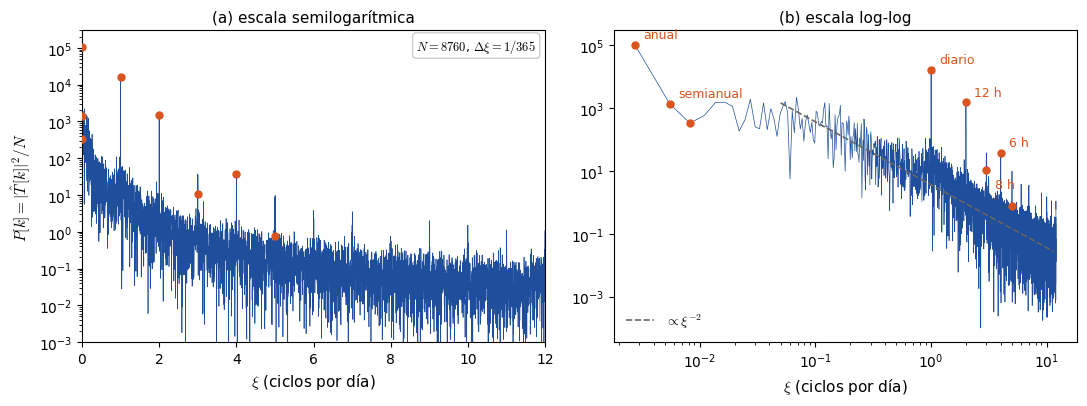

In [4]:
xi, P = espectro.periodograma(T, dt)
print(f"resolución {xi[1]:.5f} ciclos/día = 1/{1 / xi[1]:.0f} d; Nyquist {xi[-1]:.1f} ciclos/día; {len(xi)} coeficientes")

def realce(k, m=20):
    vecinos = np.r_[P[k - m:k], P[k + 1:k + m + 1]]
    return P[k] / np.median(vecinos)

candidatos = [(1, "anual"), (2, "semianual"), (3, "4 meses"), (365, "diario"), (730, "12 h"),
              (1095, "8 h"), (1460, "6 h"), (1825, "4.8 h")]
print(f"{'k':>5s} {'ξ (ciclos/día)':>15s} {'período':>10s} {'P[k]':>10s} {'realce':>9s}")
for k, nombre in candidatos:
    per = 1 / xi[k]
    print(f"{k:5d} {xi[k]:15.4f} {(f'{per:.1f} d' if per > 2 else f'{24 * per:.1f} h'):>10s} {P[k]:10.1f} {realce(k):9.1f}   {nombre}")

excl = np.zeros(len(xi), bool)
for k, _ in candidatos:
    excl[max(k - 3, 0):k + 4] = True
otros = np.argsort(-np.where(excl | (xi > 0.5), 0, P))[:5]
print("otros máximos con xi < 0.5:")
for k in otros:
    print(f"   k = {k:3d}, xi = {xi[k]:.3f} (período {1 / xi[k]:5.1f} d), P = {P[k]:7.1f}, realce {realce(k):.1f}")

m_bajo = (xi > 0.05) & (xi < 0.8)
m_alto = (xi > 5) & (xi < 11.5)
alfa_bajo = -np.polyfit(np.log(xi[m_bajo]), np.log(P[m_bajo]), 1)[0]
alfa_alto = -np.polyfit(np.log(xi[m_alto]), np.log(P[m_alto]), 1)[0]
print(f"pendiente del piso: alfa = {alfa_bajo:.2f} en [0.05, 0.8] y {alfa_alto:.2f} en [5, 11.5] ciclos/día")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.semilogy(xi[1:], P[1:], color=COLORES["dato"], lw=0.5)
ax2.loglog(xi[1:], P[1:], color=COLORES["dato"], lw=0.5)
for k, nombre in candidatos:
    for ax in (ax1, ax2):
        ax.plot(xi[k], P[k], "o", color=COLORES["modelo"], ms=5, zorder=5)
    if k in (1, 2, 365, 730, 1095, 1460):
        ax2.annotate(nombre, (xi[k], P[k]), (6, -13) if k == 1095 else (6, 5), textcoords="offset points", fontsize=9, color=COLORES["modelo"])
xx = np.array([0.05, 11.5])
ax2.plot(xx, np.exp(np.polyval([-2, np.log(P[m_bajo]).mean() + 2 * np.log(xi[m_bajo]).mean()], np.log(xx))),
         "--", color="0.4", lw=1.2, label=r"$\propto \xi^{-2}$")
ax2.legend(loc="lower left")
ax1.set_xlim(0, 12); ax1.set_ylim(1e-3, 3e5); ax1.set_xlabel(r"$\xi$ (ciclos por día)"); ax1.set_ylabel(r"$P[k] = |\hat T[k]|^2/N$")
ax1.set_title("(a) escala semilogarítmica"); ax2.set_title("(b) escala log-log")
ax2.set_xlabel(r"$\xi$ (ciclos por día)")
estilo.parametros(ax1, f"$N = {N}$, $\\Delta\\xi = 1/365$", loc="upper right")
fig.tight_layout()

In [5]:
# Verificación
assert xi.shape == P.shape == (N // 2 + 1,) and abs(xi[1] - 1 / 365) < 1e-9 and abs(xi[-1] - 12) < 1e-9, "xi debe estar en ciclos por día (dt en días)"
assert realce(365) > 50 and realce(1) > 5, "los picos diario y anual deben sobresalir muchísimo del piso"
assert realce(730) > 50 and realce(1095) > 5 and realce(1460) > 10, "los armónicos de 12 h, 8 h y 6 h sobresalen del piso"
assert 1.2 < alfa_bajo < 2.6 and 1.2 < alfa_alto < 2.6, "el piso decae con una pendiente cercana a -2: ¿pasaste logaritmos de xi y de P?"
print("espectro de potencia: OK")

espectro de potencia: OK


**Para el docente (Tarea 2).** Realces (mediana de $\pm 20$ vecinos): anual 162, semianual 2.3, cuatro meses 0.5, diario 744, 12 h 660, 8 h 14, 6 h 82, 4.8 h 3.3. Con $P[k]$: 104737, 1386, 329, 16652, 1502, 10.9, 36.3, 0.8. Es la primera sorpresa del laboratorio: **el semianual no es un pico** (su amplitud, 0.80 °C, es comparable a las fluctuaciones de baja frecuencia de su entorno; un solo año no alcanza). El 8 h sí sobresale, pero menos que el de 6 h (0.13 °C contra 0.07 °C): el ciclo diario no es simétrico (sube rápido a la mañana y baja lento a la noche), así que no tiene solo los tres primeros armónicos. Los cinco máximos más altos a baja frecuencia fuera de los candidatos: períodos de 14.6, 36.5, 18.2, 8.3 y 28.1 días, con realces de 3 a 6: son fluctuaciones del ruido rojo (el periodograma tiene dispersión del 100 %), no ciclos. Pendientes del piso: $\alpha = 1.84$ en $[0.05, 0.8]$ y $1.96$ en $[5, 11.5]$: ley de potencias $\xi^{-2}$ (potencia que decae como $1/\xi^2$ es la de un paseo al azar: la temperatura de hoy es la de ayer más un cambio aleatorio, con memoria de varios días). Errores típicos: `dt = 1` (todo queda en ciclos por hora: el diario en $1/24$), graficar `P[0]` (que es cero, la media restada) en `semilogy`, ajustar la pendiente incluyendo los picos. Tiempo: 30 minutos. **Discrepancia con las notas**: el notebook `08-aplicaciones` y el texto tratan a $k = 2$ como pico (conserva $k = 1, 2, 365, 730, 1095$); en el laboratorio se conserva igual (para reproducir el 71 %), pero se lo discute.

## 3. Amplitud y fase de una componente

Si en la señal hay una componente $A\cos(2\pi\xi t + \varphi)$ con $\xi = \xi_k$ en la grilla, la DFT la ve en el coeficiente $k$, y con la convención de `numpy` ($\hat x[k] = \sum_j x_j e^{-2\pi i jk/N}$, $t_j = j\Delta t$ con el origen en el primer dato)

$$A = \frac{2\,|\hat x[k]|}{N}, \qquad \varphi = \arg \hat x[k].$$

(El factor 2 aparece porque la energía de un coseno se reparte entre $+k$ y $-k$.) Es lo que devuelve `espectro.amplitudes(x, dt)`. La componente alcanza su **máximo** cuando el argumento del coseno vale $0$ módulo $2\pi$: $2\pi\xi t^* + \varphi = 0$, es decir

$$t^* = -\frac{\varphi}{2\pi\xi} \pmod{1/\xi}.$$

Con $t = 0$ en el 1/1/2023 a las 00:00, $t^*$ está en días desde esa fecha. Para el ciclo anual, $t^*$ da la fecha; para el diario ($1/\xi$ = 1 día), la parte fraccionaria de $t^*$ por 24 es la hora del día. Cuidado con el signo de $\varphi$ y con reducir módulo el período: es el error más común.

### Estimar por mínimos cuadrados con frecuencia fija

Otra manera de estimar la misma componente, que conocen de Estadística, es un **modelo lineal**: como $A\cos(2\pi\xi t + \varphi) = a\cos(2\pi\xi t) + b\sin(2\pi\xi t)$ con $a = A\cos\varphi$, $b = -A\sin\varphi$, si $\xi$ es conocida los parámetros $(a, b)$ (y la media $c$) resultan de una regresión lineal $x_j \approx c + a\cos(2\pi\xi t_j) + b\sin(2\pi\xi t_j)$, con $A = \sqrt{a^2 + b^2}$ y $\varphi = \operatorname{atan2}(-b, a)$. Se pueden agregar varias frecuencias como columnas de la matriz de diseño. Si las frecuencias están en la grilla del tramo, las columnas son ortogonales entre sí y **DFT y mínimos cuadrados dan exactamente lo mismo**; si no, dan distinto, y el de mínimos cuadrados tiene razón (siempre que se conozca la frecuencia):

* **Con la DFT**, una frecuencia que no está en la grilla se reparte entre coeficientes vecinos y el pico más alto subestima la amplitud (hasta un 36 % si la frecuencia queda justo entre dos coeficientes).
* **Por mínimos cuadrados** se ajusta la frecuencia exacta, sin depender de la grilla; a cambio, hay que *saber* qué frecuencias poner.

Esto importa en la tercera consigna: para ver cómo cambia el ciclo diario en la estación fría y en la cálida hay que mirar tramos cortos, y ahí la grilla es gruesa ($\Delta\xi = 1/T$).

### Tarea 3: Amplitud y fase de los ciclos anual y diario

1. Con `xi_a, A, phi = espectro.amplitudes(T, dt)`, calculá la amplitud $A_1$ y la fase del ciclo anual ($k = 1$) y del diario ($k = 365$). A partir de la fase, obtené el **día del año del máximo anual** (`fecha_max_anual`, un `pd.Timestamp`: `fecha.iloc[0] + pd.Timedelta(days=...)`) y la **hora del máximo diario** (`hora_max_diaria`, en horas decimales). Guardá también `A_anual`, `A_diaria`.
2. Escribí `ajuste_ls(x, t, frecs)` que ajusta por mínimos cuadrados (`np.linalg.lstsq`) $x \approx c + \sum_f a_f \cos(2\pi f t) + b_f\sin(2\pi f t)$ y devuelve `(c, A, phi)` con `A`, `phi` arreglos (uno por frecuencia). Aplicala a `frecs = [1/365, 1]` (guardá `A_ls`, `phi_ls`) y verificá que coincide con la DFT hasta el error de redondeo. ¿Por qué coincide?
3. **Estacionalidad del ciclo diario.** Recortá enero y julio de 2023 (`fecha.dt.month`), y calculá para cada mes la amplitud del ciclo diario con la DFT del mes (¿en qué $k$ cae $\xi = 1$ ciclo/día en un tramo de 31 días?). Guardá `A_enero`, `A_julio`. Calculá también la hora del máximo diario de cada mes.
4. **Cuando la grilla no alcanza.** Tomá un tramo de 10 días y medio (252 horas) de enero, `T[120:120 + 252]`: ahí $\xi = 1$ ciclo/día queda justo entre dos coeficientes. Compará la amplitud diaria que da el pico más alto de la DFT (`espectro.amplitudes`, coeficiente más cercano a $\xi = 1$) con la del ajuste `ajuste_ls` con $\xi = 1$ fijo (`A_dft_corto`, `A_ls_corto`) y con `A_enero`.

**Qué se espera.** $A_1 \approx 6.9$ °C con máximo el 25 de enero; $A_{365} \approx 2.8$ °C con máximo alrededor de las 15:45; el ciclo diario es más marcado en enero ($\approx 3.0$ °C) que en julio ($\approx 2.3$ °C). En el tramo de 10.5 días, la DFT subestima mucho la amplitud (alrededor de $2$ °C) y mínimos cuadrados da un valor cercano al de enero completo (más de $3$ °C).

In [6]:
xi_a, A, phi = espectro.amplitudes(T, dt)
k_an, k_di = 1, 365

def instante_max(k, phi=phi, xi=xi_a):
    return (-phi[k] / (2 * np.pi * xi[k])) % (1 / xi[k])       # días desde el origen, reducido al período

A_anual, A_diaria = A[k_an], A[k_di]
fecha_max_anual = fecha.iloc[0] + pd.Timedelta(days=instante_max(k_an))
hora_max_diaria = 24 * instante_max(k_di)
print(f"anual : A = {A_anual:.3f} °C, fase = {phi[k_an]:+.3f} rad, máximo el {fecha_max_anual:%d/%m a las %H:%M}")
print(f"diario: A = {A_diaria:.3f} °C, fase = {phi[k_di]:+.3f} rad, máximo a las {int(hora_max_diaria)}:{int(60 * (hora_max_diaria % 1)):02d}")

def ajuste_ls(x, t, frecs):
    cols = [np.ones_like(t)]
    for f in frecs:
        cols += [np.cos(2 * np.pi * f * t), np.sin(2 * np.pi * f * t)]
    coef, *_ = np.linalg.lstsq(np.column_stack(cols), x, rcond=None)
    a, b = coef[1::2], coef[2::2]
    return coef[0], np.hypot(a, b), np.arctan2(-b, a)

c_ls, A_ls, phi_ls = ajuste_ls(T, t, [1 / 365, 1])
print(f"mínimos cuadrados: media {c_ls:.4f}, A = {A_ls.round(4)}, fase = {phi_ls.round(4)}")
print(f"diferencia con la DFT: {abs(A_ls[0] - A[k_an]):.1e}, {abs(A_ls[1] - A[k_di]):.1e} (amplitudes), "
      f"{abs(phi_ls[0] - phi[k_an]):.1e}, {abs(phi_ls[1] - phi[k_di]):.1e} (fases)")

def diaria(mes):
    x = T[fecha.dt.month == mes]
    xi, Am, ph = espectro.amplitudes(x, dt)
    k = np.argmin(abs(xi - 1))                 # xi = 1 ciclo/día: k = 31 para un tramo de 31 días
    return Am[k], 24 * ((-ph[k] / (2 * np.pi * xi[k])) % (1 / xi[k])), xi[k], k

A_enero, h_enero, xk, kk = diaria(1)
A_julio, h_julio, _, _ = diaria(7)
print(f"ciclo diario, DFT de cada mes (xi = {xk:.3f} en k = {kk}): enero A = {A_enero:.2f} °C, máx. a las {h_enero:.1f} h; "
      f"julio A = {A_julio:.2f} °C, máx. a las {h_julio:.1f} h")

x_c = T[120:120 + 252]; t_c = np.arange(252) * dt
xi_c, A_c, _ = espectro.amplitudes(x_c, dt)
kc = np.argmin(abs(xi_c - 1))
A_dft_corto = A_c[kc]
A_ls_corto = ajuste_ls(x_c, t_c, [1.0])[1][0]
print(f"tramo de 10.5 días: coeficiente más cercano a xi = 1 es xi[{kc}] = {xi_c[kc]:.3f}; "
      f"A por DFT = {A_dft_corto:.2f} °C ({100 * A_dft_corto / A_ls_corto:.0f} % del valor por mínimos cuadrados), A por mínimos cuadrados = {A_ls_corto:.2f} °C (enero completo: {A_enero:.2f})")

anual : A = 6.916 °C, fase = -0.419 rad, máximo el 25/01 a las 07:56
diario: A = 2.757 °C, fase = +2.164 rad, máximo a las 15:44
mínimos cuadrados: media 18.2421, A = [6.9156 2.7575], fase = [-0.4188  2.1639]
diferencia con la DFT: 8.9e-16, 4.9e-15 (amplitudes), 2.2e-16, 1.1e-13 (fases)
ciclo diario, DFT de cada mes (xi = 1.000 en k = 31): enero A = 3.00 °C, máx. a las 15.6 h; julio A = 2.26 °C, máx. a las 16.0 h
tramo de 10.5 días: coeficiente más cercano a xi = 1 es xi[11] = 1.048; A por DFT = 1.99 °C (63 % del valor por mínimos cuadrados), A por mínimos cuadrados = 3.13 °C (enero completo: 3.00)


In [7]:
# Verificación
assert abs(A_anual - 6.92) < 0.05 and abs(A_diaria - 2.76) < 0.05, "amplitudes: A_1 ~ 6.9 °C, A_365 ~ 2.8 °C"
assert fecha_max_anual.month == 1 and 20 <= fecha_max_anual.day <= 30, "el máximo anual cae a fines de enero (cuidado con el signo de la fase y con el módulo)"
assert 15 <= hora_max_diaria <= 16.5, "el máximo diario cae a media tarde (~15:45)"
assert np.allclose(A_ls, [A[1], A[365]], atol=1e-6) and np.allclose(phi_ls, [phi[1], phi[365]], atol=1e-6), "DFT y mínimos cuadrados deberían coincidir sobre la grilla"
assert A_enero > A_julio + 0.4, "el ciclo diario es más marcado en enero que en julio"
assert A_dft_corto < 0.8 * A_ls_corto and abs(A_ls_corto - A_enero) < 0.5, "en el tramo corto la DFT subestima; mínimos cuadrados no"
print("amplitud y fase: OK")

amplitud y fase: OK


## 4. Varianza explicada e identidad de Parseval

La **identidad de Plancherel discreta** dice que $\sum_{j} x_j^2 = \frac1N\sum_{k=0}^{N-1}|\hat x[k]|^2$. Con la media restada ($\hat x[0] = 0$), el miembro izquierdo es $N\operatorname{Var}(x)$ (con $\operatorname{Var}$ **sin** corrección $N/(N-1)$: `np.var` por defecto), y queda

$$\operatorname{Var}(x) = \frac1{N^2}\sum_{k\ne0}|\hat x[k]|^2 .$$

Cada frecuencia contribuye a la varianza con su parte: para una señal real, $k$ y $N-k$ contribuyen igual, así que un ciclo en $\xi_k$ (con $0<k<N/2$) explica la fracción $2P[k]/\sum_{k\neq0}P[k]$ de la varianza. Fijate que **es un porcentaje de la varianza (la variabilidad alrededor de la media), no de la señal**, y que coincide con el $R^2$ de la regresión con esas componentes: para una componente de amplitud $A$ sola, $\operatorname{Var} = A^2/2$ (el promedio de $\cos^2$ es $1/2$). Es una manera de chequear la cuenta: con $A_1$ y $A_{365}$ de la tarea anterior tiene que dar lo mismo.

Un par de cuidados: (i) la varianza explicada por *sumar* componentes es la suma de las de cada una porque las columnas de la DFT son ortogonales; (ii) los picos de la DFT tienen "hombros" (frecuencias vecinas) que no se cuentan si se toma un solo $k$: eso subestima el porcentaje real de los ciclos.

### Tarea 4: Varianza explicada

1. Verificá numéricamente Parseval con la serie de 2023: `X = np.fft.fft(T)` y que $\sum_{k\ne0}|\hat T[k]|^2/N$ coincide con `N * T.var()` (`E_tot`).
2. Escribí `fraccion(ks)` que devuelve la fracción de la varianza explicada por las componentes en los índices `ks` (contando $\pm k$), y calculá la de cada ciclo por separado (anual $k=1$; semianual $2$; diario $365$; 12 h $730$; 8 h $1095$) y las acumuladas: anual + diario; anual + diario + armónicos de 12 h y 8 h; y todos los anteriores más el semianual. Guardá esta última en `frac_picos`.
3. Verificá con la fórmula $A^2/2$ (dividida por la varianza) el porcentaje del ciclo anual y del diario.
4. Hacé un gráfico de barras (o una tabla) con el aporte de cada uno y el resto ("irregular").

**Qué se espera.** El ciclo anual explica cerca del 60 % y el diario cerca del 9.5 %; anual + diario, 69–70 %; con todos los picos, entre el 70 y el 71 %. Es decir, casi un tercio de la varianza de la temperatura horaria **no** es regular: es la variabilidad de los frentes, que en el espectro no forma picos. Anotá el porcentaje y una frase sobre qué significa que un ciclo "explique el 60 %".

Parseval: sum_(k != 0) |X[k]|²/N = 349929.35,  N var(T) = 349929.35
     anual (k =    1): 59.86 % de la varianza
 semianual (k =    2):  0.79 % de la varianza
    diario (k =  365):  9.52 % de la varianza
      12 h (k =  730):  0.86 % de la varianza
       8 h (k = 1095):  0.01 % de la varianza
                  anual + diario: 69.38 %
     anual + diario + 12 h + 8 h: 70.24 %
   todos los picos (+ semianual): 71.04 %
con A²/2 / var: anual 59.86 %, diario 9.52 %
irregular: 29.0 % de la varianza (desvío 3.40 °C de 6.32 °C)


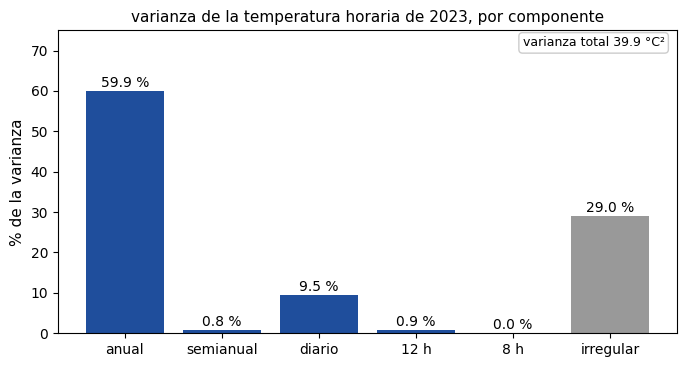

In [8]:
X = np.fft.fft(T)
E_tot = np.sum(np.abs(X[1:]) ** 2) / N
print(f"Parseval: sum_(k != 0) |X[k]|²/N = {E_tot:.2f},  N var(T) = {N * T.var():.2f}")

def fraccion(ks):
    ks = np.atleast_1d(ks)
    return 2 * np.sum(np.abs(X[ks]) ** 2) / N / E_tot

ciclos = [("anual", [1]), ("semianual", [2]), ("diario", [365]), ("12 h", [730]), ("8 h", [1095])]
for nombre, ks in ciclos:
    print(f"{nombre:>10s} (k = {ks[0]:4d}): {100 * fraccion(ks):5.2f} % de la varianza")
casos = {"anual + diario": [1, 365],
         "anual + diario + 12 h + 8 h": [1, 365, 730, 1095],
         "todos los picos (+ semianual)": [1, 2, 365, 730, 1095]}
for nombre, ks in casos.items():
    print(f"{nombre:>32s}: {100 * fraccion(ks):5.2f} %")
frac_picos = fraccion([1, 2, 365, 730, 1095])
print(f"con A²/2 / var: anual {100 * A_anual ** 2 / 2 / T.var():.2f} %, diario {100 * A_diaria ** 2 / 2 / T.var():.2f} %")
print(f"irregular: {100 * (1 - frac_picos):.1f} % de la varianza (desvío {np.sqrt((1 - frac_picos) * T.var()):.2f} °C de {T.std():.2f} °C)")

nombres = [c[0] for c in ciclos] + ["irregular"]
valores = [100 * fraccion(c[1]) for c in ciclos] + [100 * (1 - frac_picos)]
fig, ax = plt.subplots(figsize=(7, 3.8))
barras = ax.bar(nombres, valores, color=[CICLO[0]] * 5 + ["0.6"])
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f} %", ha="center", fontsize=10)
ax.set_ylabel("% de la varianza"); ax.set_ylim(0, 75)
ax.set_title("varianza de la temperatura horaria de 2023, por componente")
estilo.parametros(ax, f"varianza total {T.var():.1f} °C²", loc="upper right")
fig.tight_layout()

In [9]:
# Verificación
assert np.isclose(E_tot, N * T.var()), "Parseval: la suma sobre k != 0 de |X|^2/N es N * var (con ddof = 0)"
assert 0.59 < fraccion([1]) < 0.61 and 0.09 < fraccion([365]) < 0.10, "anual ~60 %, diario ~9.5 %"
assert np.isclose(fraccion([1]), A_anual ** 2 / 2 / T.var(), atol=1e-6), "el % del anual debe coincidir con A^2/2/var"
assert 0.70 < frac_picos < 0.72, "todos los picos: ~71 %"
print(f"varianza explicada por los picos: {100 * frac_picos:.1f} %: OK")

varianza explicada por los picos: 71.0 %: OK


**Para el docente (Tareas 3 y 4).** *Tarea 3:* $A_1 = 6.916$ °C, fase $-0.419$ rad, máximo el 25/1 a las 07:56 ($t^* = 24.33$ días); $A_{365} = 2.757$ °C, fase $2.164$ rad, máximo a las 15:44. Mínimos cuadrados con dos frecuencias coincide con la DFT a $10^{-15}$ (columnas ortogonales sobre la grilla). Enero: $A = 3.00$ °C con el máximo a las 15.6 h (15:36); julio: $2.26$ °C a las 16.0 h. Tramo de 10.5 días (`T[120:372]`): la DFT da $1.99$ °C (63 % del valor verdadero; el coeficiente más cercano es $\xi = 1.048$) y mínimos cuadrados $3.13$ °C (enero completo: $3.00$). Error típico: la fase con el signo mal ($t^* = +\varphi/(2\pi\xi)$) o sin el módulo (una fecha negativa); usar `hora = 24 * t_max` sin reducir el módulo del período. *Tarea 4:* anual 59.86 %, semianual 0.79 %, diario 9.52 %, 12 h 0.86 %, 8 h 0.01 %; acumulados: anual + diario 69.4 %, con 12 h y 8 h 70.2 %, con el semianual 71.0 % (coincide con `08-aplicaciones`); irregular 29.0 % (desvío 3.40 °C de 6.32). Parseval: $N\operatorname{Var} = 349\,929.3$. Errores típicos: no duplicar $\pm k$ (todo sale a la mitad: 30 % y 4.8 %), incluir el término $k = 0$ (la media aporta el 89 % de $\sum x_j^2$), usar `np.var(ddof=1)`. Tiempo: 40 minutos las dos.

## 5. Fuga espectral y ventana de Hann

### Por qué aparece la fuga

La DFT de un tramo de $N$ muestras equivale a multiplicar la señal (infinita) por una **ventana rectangular** que vale 1 en el tramo y 0 fuera, y transformar. El producto en el tiempo es una convolución en frecuencia: cada frecuencia de la señal aparece en el espectro **ensanchada por la transformada de la ventana**, que para la rectangular es un $\operatorname{sinc}$: un lóbulo central de ancho $2/T$ y lóbulos laterales que decaen lentamente (como $1/(\xi - \xi_0)$ en amplitud). Si $\xi_0$ es un múltiplo de $1/T$, la grilla de la DFT cae justo en los ceros del $\operatorname{sinc}$ y solo se ve el centro: un pico limpio. Si no, la grilla muestrea el sinc en puntos intermedios y **la energía de la componente "se fuga" a los coeficientes vecinos** en una cola que decae lentamente. Efectos en la práctica:

* el pico más alto **subestima** la amplitud (hasta 36 % si $\xi_0$ queda justo entre dos coeficientes);
* la cola de un pico grande **tapa** picos pequeños vecinos y eleva el piso: en un espectro con picos de $10^5$ y un piso de $10^{-1}$, una cola que decae como $1/\xi$ en amplitud ($1/\xi^2$ en potencia) puede dominar el piso lejos del pico;
* es equivalente a mirar el "salto" entre el final y el comienzo del tramo: una señal no periódica en $T$ tiene un salto, y un salto tiene un espectro que decae como $1/\xi$ en amplitud.

### Ventanas

El remedio es **suavizar los bordes**: multiplicar el tramo por una ventana $w[j]$ que baja a cero suavemente en los dos extremos. La **ventana de Hann** es $w[j] = \frac12\bigl(1 - \cos\frac{2\pi j}{N-1}\bigr)$ (`np.hanning(N)`). Su transformada tiene lóbulos laterales que decaen mucho más rápido (como $1/\xi^3$ en amplitud), a cambio de un **lóbulo central más ancho** (el doble: $4/T$ en lugar de $2/T$: pierde resolución). Es el compromiso de siempre: menos fuga contra menos resolución. Al multiplicar por $w$ el pico también baja (la ventana atenúa la señal, en promedio a la mitad de su amplitud), y hay que normalizar para comparar: `espectro.periodograma(x, dt, ventana="hann")` divide por $N\,\overline{w^2}$ para que la potencia total se conserve; si en cambio querés **la amplitud** de una componente de un espectro con ventana, la estimación es $A \approx 2\,|\hat{(xw)}[k]|/\sum_j w[j]$.

Una ventaja menos conocida de Hann: el error por "estar entre dos coeficientes" es mucho menor (la subestimación máxima de la amplitud pasa de 36 % a 15 %).

### Cómo medirlo

Antes de mirar la temperatura conviene un **control con una señal cuyo espectro se conoce**: un coseno puro de amplitud 1 y frecuencia $\xi_0 = 1$ ciclo/día en un tramo que *no* contiene un número entero de períodos (10 días y medio), con y sin ventana. Todo lo que aparezca fuera de $\xi_0$ es fuga. Después se mira lo mismo con la serie real.

### Tarea 5: Rectangular contra Hann

1. **Control sintético.** Construí `x = np.cos(2*np.pi*t_c)` con `t_c = np.arange(252) * dt` (10.5 días, $\xi_0 = 1$, amplitud 1). Calculá los periodogramas rectangular y con Hann (`espectro.periodograma(..., ventana="hann")`), y graficalos juntos con `semilogy` para $\xi \in [0, 4]$. Leé la amplitud del pico más alto en cada caso: para el rectangular $A = 2|\hat x[k]|/N$; para Hann, $A = 2|\widehat{xw}[k]|/\sum w$ (las variables `A_rect_sint`, `A_hann_sint`). Repetí con un tramo de 240 horas (10 días exactos) como referencia.
2. **Serie real, un año.** Los periodogramas de `T` (2023) rectangular y con Hann, graficados juntos cerca del pico diario ($\xi \in [0.9, 1.1]$) y cerca del pico anual ($\xi \in [0, 0.02]$). Anotá: alturas de los picos, cuántos coeficientes forman cada pico, y cuánta potencia hay en las bandas "piso" $\xi \in [3.3, 3.6]$ y $[8, 9]$ con cada ventana (`piso_rect`, `piso_hann`, en la banda $[3.3, 3.6]$).
3. **Serie real, un tramo que no es un año exacto.** Repetí (2) con `T[1416:1416 + 2412]` (100.5 días desde el 1/3/2023): el ciclo diario cae otra vez entre dos coeficientes. ¿Qué cambia con la ventana en el pico y lejos del pico?

**Qué se espera.** En el control: con el tramo de 10.5 días, el rectangular lee una amplitud cercana a $0.64$ y una cola que decae lentamente ("cola de sinc"), y Hann lee una amplitud cercana a $0.85$ con una cola que cae varios órdenes de magnitud más rápido, aunque con un pico más ancho; con 10 días exactos, los dos leen $\approx 1$ (Hann reparte el pico en tres coeficientes). En 2023 (con los picos en la grilla) el rectangular ve un pico de un solo coeficiente y Hann uno de tres (más ancho y más bajo, con las "alas" que suben), y el piso lejos de los picos baja poco (del orden del 10 al 30 %): en la serie real el piso ya es mucho más alto que la fuga del sinc, y solo en el control se ve limpia. Lo que importa es *dónde* ayuda la ventana: cerca de picos fuertes que no están en la grilla.

control, 10.5 días (xi_0 entre dos coeficientes): amplitud leída 0.65 (rectangular) y 0.85 (Hann); verdadera: 1
control, 10 días exactos: 1.00 (rectangular) y 1.00 (Hann)
cola del control (potencia media en xi in [2.5, 3.5]) relativa al pico: 1.3e-03 (rectangular), 2.8e-09 (Hann)
2023: pico diario  P[364..366] rectangular = [  180. 16652.   176.], Hann = [1804. 9627. 2305.]
2023: piso [3.3, 3.6]: 0.49 (rectangular), 0.44 (Hann); piso [8, 9]: 0.089, 0.069
tramo de 100.5 días: piso [3.3, 3.6]: 0.58 (rectangular), 0.54 (Hann); [8, 9]: 0.093, 0.062


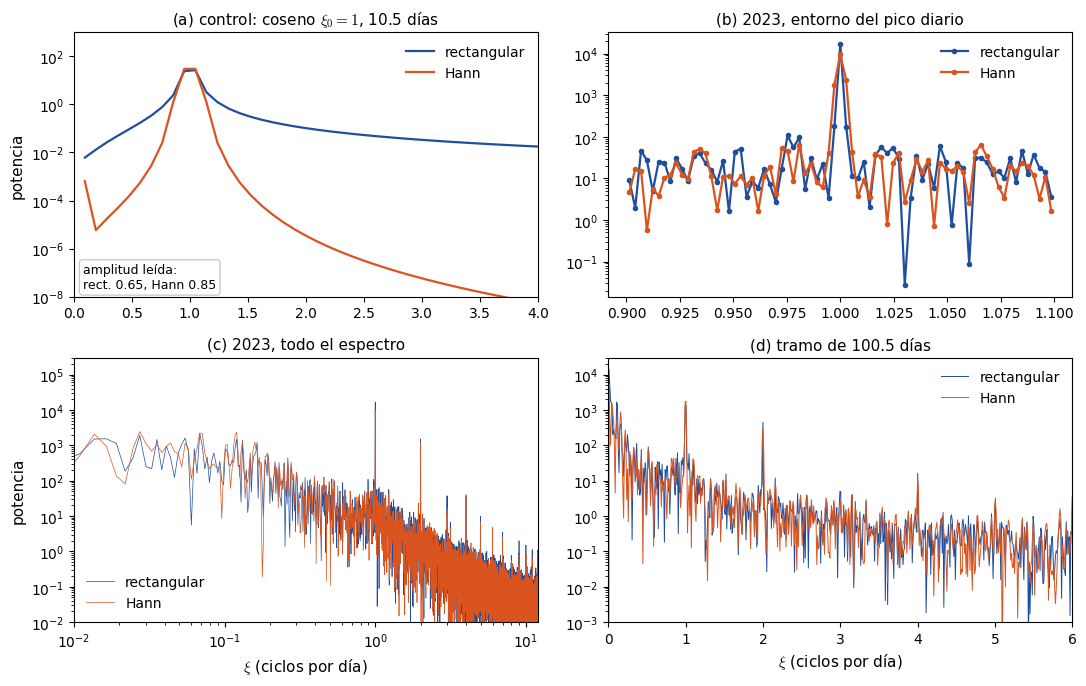

In [10]:
def amp_pico(x, ventana=None):
    # amplitud leída en el coeficiente más alto de la DFT (con la media restada)
    x = np.asarray(x, float) - np.mean(x)
    w = np.ones(len(x)) if ventana is None else np.hanning(len(x))
    X = np.fft.rfft(x * w)
    return 2 * np.abs(X).max() / w.sum()

n_c = 252
t_c = np.arange(n_c) * dt
x_sint = np.cos(2 * np.pi * t_c)
xs, P_rect = espectro.periodograma(x_sint, dt)
_, P_hann = espectro.periodograma(x_sint, dt, ventana="hann")
A_rect_sint, A_hann_sint = amp_pico(x_sint), amp_pico(x_sint, "hann")
x_exacto = np.cos(2 * np.pi * np.arange(240) * dt)
print(f"control, 10.5 días (xi_0 entre dos coeficientes): amplitud leída {A_rect_sint:.2f} (rectangular) y {A_hann_sint:.2f} (Hann); verdadera: 1")
print(f"control, 10 días exactos: {amp_pico(x_exacto):.2f} (rectangular) y {amp_pico(x_exacto, 'hann'):.2f} (Hann)")
i0 = np.argmax(P_rect)
lejos = (xs > 2.5) & (xs < 3.5)
print(f"cola del control (potencia media en xi in [2.5, 3.5]) relativa al pico: {P_rect[lejos].mean() / P_rect.max():.1e} (rectangular), "
      f"{P_hann[lejos].mean() / P_hann.max():.1e} (Hann)")

def banda(x, dt_, lo, hi, ventana=None):
    xi_, P_ = espectro.periodograma(x, dt_, ventana=ventana)
    return P_[(xi_ >= lo) & (xi_ < hi)].mean()

xi_r, P_r = espectro.periodograma(T, dt)
_, P_h = espectro.periodograma(T, dt, ventana="hann")
piso_rect, piso_hann = banda(T, dt, 3.3, 3.6), banda(T, dt, 3.3, 3.6, "hann")
k1 = 365
print(f"2023: pico diario  P[364..366] rectangular = {P_r[k1 - 1:k1 + 2].round(0)}, Hann = {P_h[k1 - 1:k1 + 2].round(0)}")
print(f"2023: piso [3.3, 3.6]: {piso_rect:.2f} (rectangular), {piso_hann:.2f} (Hann); piso [8, 9]: {banda(T, dt, 8, 9):.3f}, {banda(T, dt, 8, 9, 'hann'):.3f}")
x_t = T[1416:1416 + 2412]
xi_t, P_t = espectro.periodograma(x_t, dt)
_, P_th = espectro.periodograma(x_t, dt, ventana="hann")
print(f"tramo de 100.5 días: piso [3.3, 3.6]: {banda(x_t, dt, 3.3, 3.6):.2f} (rectangular), {banda(x_t, dt, 3.3, 3.6, 'hann'):.2f} (Hann); "
      f"[8, 9]: {banda(x_t, dt, 8, 9):.3f}, {banda(x_t, dt, 8, 9, 'hann'):.3f}")

fig, axs = plt.subplots(2, 2, figsize=(11, 7))
ax = axs[0, 0]
ax.semilogy(xs[1:], P_rect[1:], color=COLORES["dato"], label="rectangular")
ax.semilogy(xs[1:], P_hann[1:], color=COLORES["modelo"], label="Hann")
ax.set_xlim(0, 4); ax.set_ylim(1e-8, 1e3); ax.legend(loc="upper right")
ax.set_title(f"(a) control: coseno $\\xi_0 = 1$, 10.5 días"); ax.set_ylabel("potencia")
estilo.parametros(ax, f"amplitud leída:\nrect. {A_rect_sint:.2f}, Hann {A_hann_sint:.2f}", loc="lower left")
ax = axs[0, 1]
m = (xi_r > 0.9) & (xi_r < 1.1)
ax.semilogy(xi_r[m], P_r[m], "o-", ms=3, color=COLORES["dato"], label="rectangular")
ax.semilogy(xi_r[m], P_h[m], "o-", ms=3, color=COLORES["modelo"], label="Hann")
ax.set_title("(b) 2023, entorno del pico diario"); ax.legend(loc="upper right")
ax = axs[1, 0]
ax.loglog(xi_r[1:], P_r[1:], color=COLORES["dato"], lw=0.5, label="rectangular")
ax.loglog(xi_r[1:], P_h[1:], color=COLORES["modelo"], lw=0.5, label="Hann")
ax.set_xlim(1e-2, 12); ax.set_ylim(1e-2, 3e5); ax.legend(loc="lower left")
ax.set_title("(c) 2023, todo el espectro"); ax.set_xlabel(r"$\xi$ (ciclos por día)"); ax.set_ylabel("potencia")
ax = axs[1, 1]
ax.semilogy(xi_t, P_t, color=COLORES["dato"], lw=0.7, label="rectangular")
ax.semilogy(xi_t, P_th, color=COLORES["modelo"], lw=0.7, label="Hann")
ax.set_xlim(0, 6); ax.set_ylim(1e-3, 3e4); ax.legend(loc="upper right")
ax.set_title("(d) tramo de 100.5 días"); ax.set_xlabel(r"$\xi$ (ciclos por día)")
fig.tight_layout()

In [11]:
# Verificación
assert 0.55 < A_rect_sint < 0.75 and 0.8 < A_hann_sint < 0.92, "control (10.5 días): rectangular ~0.64 y Hann ~0.85 (con A = 2|X|/sum(w))"
assert piso_hann < piso_rect, "el piso lejos de los picos baja con Hann"
print("fuga espectral y ventanas: OK")

fuga espectral y ventanas: OK


**Para el docente (Tarea 5).** Control (coseno de amplitud 1, 10.5 días): amplitud leída 0.65 (rectangular) y 0.85 (Hann, con $A = 2|X_w|/\sum w$); con 10 días exactos ambas dan 1.00. La cola lejos del pico ($\xi \in [2.5, 3.5]$) relativa al máximo es $1.3\times10^{-3}$ para el rectangular y $2.8\times10^{-9}$ para Hann: seis órdenes de magnitud. En 2023: $P[364..366]$ es $[180,\ 16652,\ 176]$ (rectangular) y $[1804,\ 9627,\ 2305]$ (Hann); el piso en $[3.3, 3.6]$ baja de 0.49 a 0.44 y en $[8, 9]$ de 0.089 a 0.069. En el tramo de 100.5 días: 0.58 a 0.54 y 0.093 a 0.062. **El efecto en los datos reales es modesto**, mucho menos espectacular que en el control: el piso real (ruido rojo) queda por encima de la fuga, y es importante que lo vean: no es una regla que Hann "limpie" el piso, lo hace donde hay picos fuertes fuera de la grilla, y con datos como estos la cuestión aparece sobre todo al medir amplitudes en tramos cortos. Errores típicos: leer la amplitud con Hann sin dividir por $\sum w$ (sale la mitad), comparar la altura del pico del periodograma de `espectro.periodograma` entre ventanas creyendo que es la amplitud (está normalizado por potencia, no por amplitud), ver un pico de Hann "más chico" y decir que Hann pierde energía. Tiempo: 35 minutos.

## 6. Submuestreo y aliasing en datos reales

Si una señal se muestrea cada $\Delta t$, las frecuencias solo pueden distinguirse hasta la de Nyquist $\xi_N = 1/(2\Delta t)$, y una componente de frecuencia $\xi$ **fuera** de $[0, \xi_N]$ no desaparece: se **pliega** sobre otra dentro de la banda. Con frecuencia de muestreo $f_s = 1/\Delta t$, la frecuencia observada (el *alias*) es

$$\xi_{\text{alias}} = \bigl|\,\xi - f_s\, \operatorname{round}(\xi/f_s)\bigr| \in [0, \xi_N].$$

Por ejemplo, con una muestra por día ($f_s = 1$ ciclo/día, $\xi_N = 0.5$), el ciclo diario ($\xi = 1$) se pliega sobre $|1 - 1\cdot1| = 0$: **la frecuencia cero, es decir, la media**. Dicho con la DFT: submuestrear una vez cada $m$ horas suma los coeficientes $\hat x[k]$ en pasos de $N/m$; en particular, la media de las mediciones de las 15 h es

$$\overline{x_{15}} = \frac1N\sum_{m=0}^{23}\hat x[365\,m]\,e^{2\pi i\, m\, 15/24},$$

que es la media general más el valor a las 15 h de todos los armónicos del ciclo diario. Es un sesgo, no ruido: cambia el promedio de la serie en una cantidad **sistemática** que depende de la hora elegida. Y cuando el período de muestreo no es un divisor del día, el ciclo diario aparece como una oscilación **falsa** de otra frecuencia: mirar una vez cada 25 horas ($f_s = 24/25 = 0.96$ ciclos/día) lo pliega sobre $|1 - 0.96| = 0.04$ ciclos/día, un ciclo de 25 días que en la serie original no existe (que exista un ciclo diario, sí).

**Qué mirar.** El espectro de la serie submuestreada (con `espectro.amplitudes(x, dt_nuevo)`, donde `dt_nuevo` es el nuevo paso en días) hasta su nueva frecuencia de Nyquist, y la comparación de medias.

### Tarea 6: Submuestrear a las 15 h y cada 25 h

1. Armá `T15`, la serie de 365 valores de las 15 h (`fecha.dt.hour == 15`), y calculá su espectro de amplitudes con `dt = 1` día. Graficalo junto con el espectro de amplitudes de la serie horaria (hasta 12 ciclos/día), con `semilogy`. ¿Dónde fue el ciclo diario? ¿Y el anual? Guardá `T15`, `media_15` y `media_horaria` y calculá la diferencia.
2. **Verificá la fórmula.** Guardá en `media_alias` el resultado de `np.real(sum(X[365*m] * np.exp(2j*np.pi*m*15/24) for m in range(24))) / N` con `X = np.fft.fft(T)`, y comprobá que es igual a `media_15`. Interpretalo: el sesgo es el valor a las 15 h del "ciclo diario medio". Calculá también la media de la serie submuestreada a las 3 h de la madrugada y a las 9 h. ¿Cuál es el signo del sesgo en cada caso?
3. **Aliasing genuino.** Submuestreá cada 25 horas: `T25 = T[::25]`, con paso `dt25 = 25/24` días. Predecí con la fórmula de arriba a qué frecuencia $\xi_{\text{alias}}$ (ciclos por día, `xi_alias_pred`) cae el ciclo diario, y verificalo: espectro de amplitudes de `T25` y amplitud máxima en el entorno $\xi_{\text{alias}} \pm 0.005$ comparada con la amplitud en ese mismo entorno de la serie horaria.

**Qué se espera.** El ciclo anual sigue en $\xi = 1/365$ con $A \approx 6.9$; el diario desapareció del espectro (con paso de 1 día solo se llega a $0.5$ ciclos/día) y su energía fue a la media: $\overline{x_{15}} \approx 21.5$ °C contra $18.2$ °C de la horaria. La fórmula da lo mismo hasta el redondeo. Con las 3 h el sesgo es negativo, con las 9 h también (la mañana es más fría que el promedio). Con la muestra cada 25 h aparece un ciclo de amplitud $\approx 2$ °C en $\xi \approx 0.04$ que en la serie horaria tiene menos de 1 °C (y de origen distinto: las fluctuaciones de los frentes): es un ciclo de 25 días que **no existe**.

T15: N = 365, Nyquist = 0.5 ciclos/día; media a las 15 h = 21.54 °C, media horaria = 18.24 °C, diferencia = +3.30 °C;  A_anual(15 h) = 6.92 °C
fórmula de los coeficientes: 21.5425  contra  21.5425
   media de las mediciones a las  3 h: 16.18 °C  (sesgo -2.06 °C)
   media de las mediciones a las  9 h: 17.15 °C  (sesgo -1.09 °C)
   media de las mediciones a las 15 h: 21.54 °C  (sesgo +3.30 °C)
cada 25 h: f_s = 0.960 ciclos/día, Nyquist 0.479; alias predicho del ciclo diario: xi = 0.040 (período 25.0 días)
   amplitud máxima en xi = 0.040 ± 0.005: 1.97 °C (submuestreada) contra 0.82 °C (horaria)


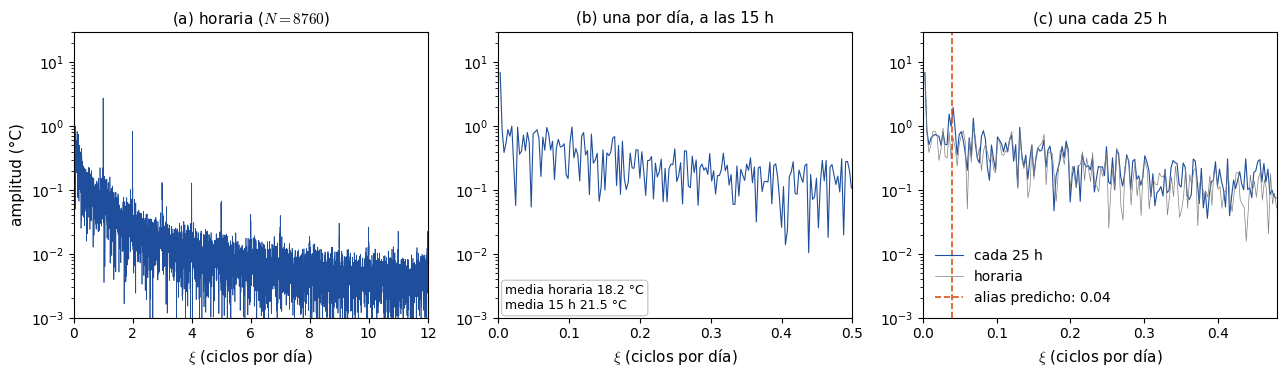

In [12]:
T15 = T[(fecha.dt.hour == 15).values]
xi15, A15, _ = espectro.amplitudes(T15, 1.0)
xi_h, A_h, _ = espectro.amplitudes(T, dt)
media_15, media_horaria = T15.mean(), T.mean()
print(f"T15: N = {len(T15)}, Nyquist = {xi15[-1]:.1f} ciclos/día; media a las 15 h = {media_15:.2f} °C, media horaria = {media_horaria:.2f} °C, "
      f"diferencia = {media_15 - media_horaria:+.2f} °C;  A_anual(15 h) = {A15[1]:.2f} °C")

X = np.fft.fft(T)
media_alias = np.real(sum(X[365 * m] * np.exp(2j * np.pi * m * 15 / 24) for m in range(24))) / N
print(f"fórmula de los coeficientes: {media_alias:.4f}  contra  {media_15:.4f}")
for h in (3, 9, 15):
    print(f"   media de las mediciones a las {h:2d} h: {T[(fecha.dt.hour == h).values].mean():.2f} °C  (sesgo {T[(fecha.dt.hour == h).values].mean() - media_horaria:+.2f} °C)")

T25 = T[::25]
dt25 = 25 / 24
fs25 = 1 / dt25
xi_alias_pred = abs(1 - fs25 * round(1 / fs25))
xi25, A25, _ = espectro.amplitudes(T25, dt25)
ent25 = (xi25 > xi_alias_pred - 0.005) & (xi25 < xi_alias_pred + 0.005)
ent_h = (xi_h > xi_alias_pred - 0.005) & (xi_h < xi_alias_pred + 0.005)
print(f"cada 25 h: f_s = {fs25:.3f} ciclos/día, Nyquist {xi25[-1]:.3f}; alias predicho del ciclo diario: xi = {xi_alias_pred:.3f} (período {1 / xi_alias_pred:.1f} días)")
print(f"   amplitud máxima en xi = {xi_alias_pred:.3f} ± 0.005: {A25[ent25].max():.2f} °C (submuestreada) contra {A_h[ent_h].max():.2f} °C (horaria)")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.9))
ax1.semilogy(xi_h[1:], A_h[1:], color=COLORES["dato"], lw=0.5)
ax1.set_xlim(0, 12); ax1.set_ylim(1e-3, 30); ax1.set_title("(a) horaria ($N = 8760$)")
ax1.set_xlabel(r"$\xi$ (ciclos por día)"); ax1.set_ylabel("amplitud (°C)")
ax2.semilogy(xi15[1:], A15[1:], color=COLORES["dato"], lw=0.8)
ax2.set_xlim(0, 0.5); ax2.set_ylim(1e-3, 30); ax2.set_title("(b) una por día, a las 15 h")
ax2.set_xlabel(r"$\xi$ (ciclos por día)")
estilo.parametros(ax2, f"media horaria {media_horaria:.1f} °C\nmedia 15 h {media_15:.1f} °C", loc="lower left", fontsize=9)
ax3.semilogy(xi25[1:], A25[1:], color=COLORES["dato"], lw=0.8, label="cada 25 h")
ax3.semilogy(xi_h[(xi_h > 0) & (xi_h < 0.48)], A_h[(xi_h > 0) & (xi_h < 0.48)], color=COLORES["gris"], lw=0.5, label="horaria")
ax3.axvline(xi_alias_pred, color=COLORES["modelo"], ls="--", lw=1.2, label=rf"alias predicho: {xi_alias_pred:.2f}")
ax3.set_xlim(0, 0.48); ax3.set_ylim(1e-3, 30); ax3.legend(loc="lower left"); ax3.set_title("(c) una cada 25 h")
ax3.set_xlabel(r"$\xi$ (ciclos por día)")
fig.tight_layout()

In [13]:
# Verificación
assert len(T15) == 365 and abs(media_15 - 21.54) < 0.05 and abs(media_horaria - 18.24) < 0.01, "medias: 21.5 (15 h) contra 18.2 (horaria)"
assert abs(espectro.amplitudes(T15, 1.0)[1][1] - 6.92) < 0.5, "el ciclo anual sigue ahí con la misma amplitud (dt = 1 día para T15)"
assert abs(media_alias - media_15) < 1e-6, "la fórmula de los coeficientes en múltiplos de 365 debe dar la media de las 15 h"
xi25_v, A25_v, _ = espectro.amplitudes(T[::25], 25 / 24)
assert abs(xi_alias_pred - 0.04) < 1e-9 and A25_v[abs(xi25_v - xi_alias_pred) < 0.005].max() > 1.5, "el ciclo diario reaparece como un ciclo de ~25 días"
print("submuestreo y aliasing: OK")

submuestreo y aliasing: OK


**Para el docente (Tarea 6).** Media a las 15 h: 21.54 °C contra 18.24 °C de la horaria (diferencia $+3.30$); la fórmula con $\hat x[365 m]$ da 21.5425 (idéntico). A las 3 h: 16.18 ($-2.06$); a las 9 h: 17.15 ($-1.09$). El ciclo anual sigue con $A = 6.92$ °C. Cada 25 h ($f_s = 0.96$, Nyquist $0.48$): alias predicho $\xi = 0.04$ (25 días); la amplitud máxima en $0.04 \pm 0.005$ es 1.97 °C contra 0.82 °C en la horaria (que es el nivel del ruido rojo ahí: no es un pico limpio, porque la amplitud del ciclo diario no es constante, y su alias se ensancha). Extensión útil: una medición por semana a las 15 h (`T[15::168]`, 53 valores) da una media de 21.74 °C: la misma historia, porque 7 días es múltiplo de 24 h. Errores típicos: pasar `dt = 1/24` a la serie submuestreada (el espectro sale comprimido), olvidar que `T[fecha.dt.hour == 15]` es una `Series` (usar `.values`), contar la frecuencia de Nyquist mal. Tiempo: 25 minutos.

## 7. Filtrar: la parte regular, el residuo y los promedios móviles

### Filtrar en frecuencia

Un **filtro** en frecuencia multiplica el espectro por una función $H(\xi)$ y antitransforma: $y = \mathcal F^{-1}\bigl(H\,\hat x\bigr)$. Con $H \in \{0, 1\}$ se conservan algunas frecuencias y se descartan las otras. Para que $y$ sea real, $H$ tiene que ser simétrica ($H(-\xi) = H(\xi)$): con `rfft` eso es automático. `espectro.filtrar(x, dt, mascara)` lo hace: `mascara(xi)` recibe el arreglo de frecuencias (en ciclos por día) y devuelve 0/1 o números reales. Como los picos caen en frecuencias que son múltiplos de $1/365$, la máscara de picos es `np.isclose(xi, f, atol=medio_ancho)` con `medio_ancho` del orden de media resolución ($0.5/365$).

El filtro "sólo los picos" (más la media) da la **temperatura regular** $T_{\rm reg}$; lo que resta, $r = T - T_{\rm reg}$, es el **residuo**, la parte "irregular". Preguntas: ¿tiene estructura? Un ruido blanco (independiente de un instante al otro) tiene un espectro plano: $E[P[k]] = \sigma^2$ para todo $k$ (con la normalización $|\hat x[k]|^2/N$), y una autocorrelación nula fuera de $0$. Una señal cuyo espectro no es plano tiene *memoria*: el valor de hoy dice algo sobre el de mañana. Para medir el espectro de un residuo, que es una señal aleatoria, el periodograma es muy ruidoso (cada $P[k]$ tiene una dispersión del mismo orden que su valor, sin importar cuánto dure el registro); se lo suaviza promediando periodogramas de tramos (**método de Welch**, `espectro.welch(x, dt, tramo=...)`) a costa de resolución.

### Promedios móviles como filtros

El **promedio móvil** de largo $L$, $y_j = \frac1L\sum_{i=0}^{L-1}x_{j-i}$, es una **convolución** con $h = (1/L, \dots, 1/L)$, y por el teorema de convolución $\hat y[k] = \hat h[k]\,\hat x[k]$: **es un filtro**, con respuesta en frecuencia $H[k] = \hat h[k]$. Se calcula sumando una progresión geométrica: con $\xi_k = k/(N\Delta t)$,

$$|H(\xi)| = \left|\frac{\sin(\pi\xi L\,\Delta t)}{L\,\sin(\pi\xi\,\Delta t)}\right| \;\approx\; \bigl|\operatorname{sinc}(\xi\, L\Delta t)\bigr| \qquad (\xi\Delta t \ll 1),$$

con $\operatorname{sinc}(u) = \sin(\pi u)/(\pi u)$. Las consecuencias:

* $H(0) = 1$: conserva la media y las variaciones más lentas que la ventana ($\xi \ll 1/(L\Delta t)$).
* **Ceros en los múltiplos de $1/(L\Delta t)$**: el promedio de *cualquier* señal periódica de período $L\Delta t/m$ sobre una ventana de $L\Delta t$ es exactamente cero. Por eso un promedio móvil de 24 h (una ventana de 1 día, ceros en $1, 2, 3, \dots$ ciclos/día) **borra exactamente el ciclo diario y todos sus armónicos**, y uno de 7 días ($L = 168$, ceros en $1/7, 2/7, \dots$ ciclos/día, que incluyen $1, 2, 3$) los borra también, y además atenúa todo lo que tenga períodos más cortos que una semana.
* **Lóbulos laterales**: entre los ceros $|H|$ no es cero, sube hasta unos $1/(\pi\,\xi L\Delta t)$: el promedio de 24 h deja pasar alrededor del $20\ \%$ de una oscilación de 16 h ($\xi = 1.5$). Es un filtro pasabajos *malo*: no corta, atenúa a los saltos, y cambia de signo ($H<0$ en los lóbulos impares: la señal filtrada tiene invertidas algunas frecuencias).

Contra el filtro "ideal" de picos (que conserva exactamente lo que se elige y anula el resto), el promedio móvil tiene la ventaja de que **no hay que elegir las frecuencias** (solo un ancho) y de ser causal y barato; pero no es selectivo. Y hacen *cosas opuestas*: el filtro de picos **se queda** con los ciclos y tira lo irregular, el promedio de 24 h **tira** el ciclo diario y se queda con lo irregular lento y el anual. Para compararlos tenés que mirarlos con ese cuidado.

Para calcular un promedio móvil centrado y periódico (la DFT supone que la serie se repite), usá `scipy.ndimage.uniform_filter1d(x, size=L, mode="wrap")`: así $|\hat y[k]/\hat x[k]| = |H(\xi_k)|$ es **exacto** y se puede comparar con la fórmula.

### Tarea 7: Temperatura regular, residuo y promedios móviles

1. **Filtro de picos.** Con `espectro.filtrar`, construí `T_reg` que conserva la media y los picos anual, semianual y diario con sus armónicos de 12 h y 8 h ($k = 1, 2, 365, 730, 1095$). Calculá `resid = T - T_reg`. Graficá un mes (por ejemplo mayo) con la señal, la temperatura regular y el residuo. Chequeá que la fracción de la energía del residuo es $1 - $ `frac_picos` (Tarea 4).
2. **¿Es blanco el residuo?** Calculá su periodograma y su espectro de Welch (`espectro.welch(resid, dt, tramo=45*24)`). Graficalos en log-log junto con la línea del ruido blanco de la misma varianza ($P = \sigma^2$, `resid.var()`), y marcá los períodos de 1 día, 1 semana y 1 mes. Calculá la fracción de la energía del residuo en las bandas de período: más de 30 días, entre 7 y 30, entre 2 y 7, entre 1 y 2, y menos de 1 día (`fracs_banda`, un diccionario o lista con estas cinco fracciones, que suman 1). ¿En qué escalas tiene más energía? Calculá la autocorrelación a 1 hora y a 24 horas.
3. **Promedios móviles.** Con `uniform_filter1d(..., mode="wrap")` calculá `T_ma24` y `T_ma7d` ($L = 24$ y $L = 168$). Graficalos sobre un mes junto con la señal. Después, estimá la **respuesta en frecuencia empírica** de cada uno, `H_emp = |rfft(y)| / |rfft(T)|` (en los coeficientes $k$ donde `|rfft(T)|` no es despreciable), y compará con la fórmula teórica, que escribís como una función `H_teo(xi, L)` (¡cuidado con $\xi = 0$!). Graficá `|H|` contra $\xi$ para $\xi \in [0, 3]$ ciclos/día (curva teórica continua y puntos empíricos), marcando los ceros. Verificá que `|H_emp|` es cero (a $10^{-10}$ o menos) en $\xi = 1, 2$ para los dos promedios. Los ceros del de 7 días en $\xi = 1/7, 2/7, \dots$ no se ven en la DFT de un año ($365/7$ no es entero: esas frecuencias no están en la grilla); verificalos con la fórmula teórica.
4. Respondé: ¿qué elimina cada promedio y qué deja? ¿En qué se diferencia el promedio de 24 h de "T menos el ciclo diario" (`T - ` la parte diaria del filtro de picos)? Miralo con las series y con los espectros.

**Qué se espera.** El residuo tiene un desvío de unos $3.4$ °C (29 % de la varianza) y un espectro que **no es plano**: $P$ baja unos cuatro órdenes de magnitud entre las escalas de semanas y de horas, con una pendiente de log-log cercana a $-2$, y la mayor parte de la energía en escalas de 2 a 30 días (los frentes, las masas de aire). La autocorrelación a 1 h es cercana a 1, así que el residuo es cualquier cosa menos independiente de un instante al otro. El promedio de 24 h anula el ciclo diario (`|H|` del orden de $10^{-16}$ en $\xi = 1$ y 2) pero deja pasar bastante en $\xi \approx 1.5$ y $2.5$; el de 7 días también, y atenúa mucho más las fluctuaciones de menos de una semana.

T_reg conserva 6 coeficientes de 4381; desvío de T = 6.32 °C, de T_reg = 5.33 °C, del residuo = 3.40 °C
fracción de la energía del residuo: 0.2896  (1 - frac_picos = 0.2896)
energía del residuo por escala de tiempo: > 30 d: 16 %, 7–30 d: 43 %, 2–7 d: 27 %, 1–2 d: 7 %, < 1 d: 8 %  (suma 1.000)
autocorrelación del residuo: 0.982 a 1 h, 0.577 a 24 h, 0.013 a 7 días
potencia de Welch: 715 en xi ~ 0.03 contra 0.124 en xi ~ 7: cociente 6e+03 (blanco: 1); varianza 11.6


L =  24: máx |H_emp - H_teo| = 4.9e-13;  |H_emp(1)| = 3.7e-16  |H_emp(2)| = 6.5e-16
L = 168: máx |H_emp - H_teo| = 6.7e-13;  |H_emp(1)| = 1.1e-16  |H_emp(2)| = 5.0e-16
|H_teo| del promedio de 7 días en xi = 1/7, 2/7: 3.9e-17, 3.9e-17  (la grilla de un año no contiene a 1/7)
|H_ma24| en xi = 1.5: 0.21;  en 2.5: 0.13
desvío de (T - MA24) = 2.38 °C; desvío de (T - ciclos diarios) = 2.04 °C; desvío de (MA24 - (T - ciclos diarios)) = 1.23 °C


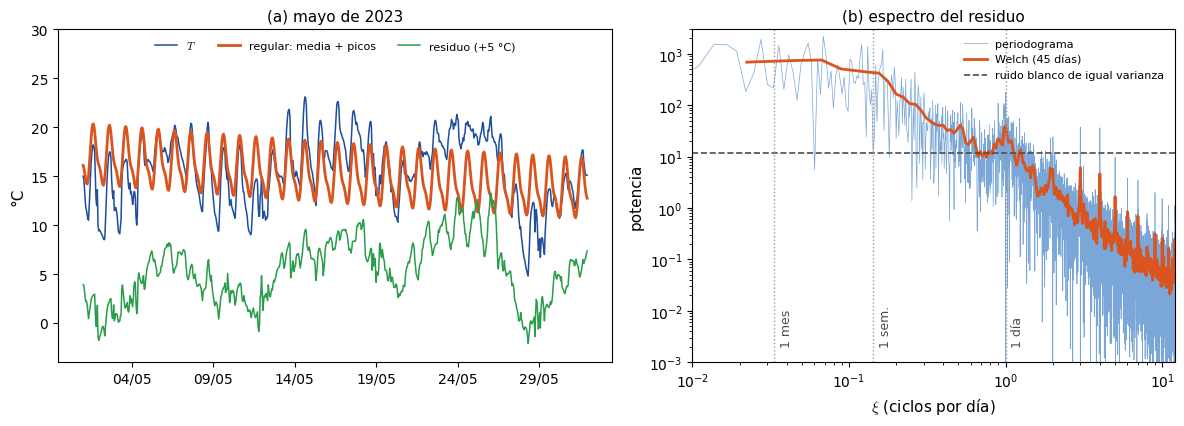

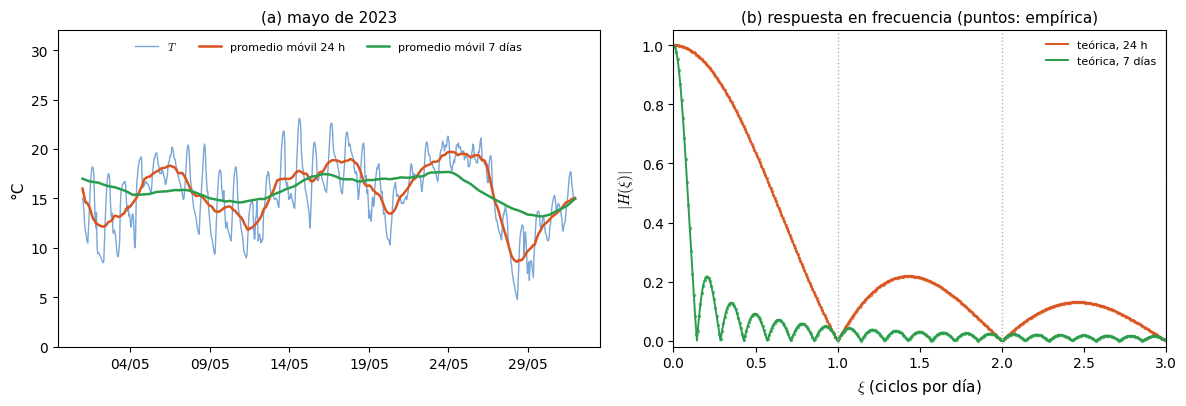

In [14]:
from scipy.ndimage import uniform_filter1d

xi_f = np.fft.rfftfreq(N, dt)
picos = [1, 2, 365, 730, 1095]
def mascara(xi):
    m = np.isclose(xi, 0, atol=0.5 / 365)
    for k in picos:
        m |= np.isclose(xi, k / 365, atol=0.5 / 365)
    return m.astype(float)

T_reg = espectro.filtrar(T, dt, mascara)
resid = T - T_reg
print(f"T_reg conserva {int(mascara(xi_f).sum())} coeficientes de {len(xi_f)}; desvío de T = {T.std():.2f} °C, de T_reg = {T_reg.std():.2f} °C, del residuo = {resid.std():.2f} °C")
print(f"fracción de la energía del residuo: {resid.var() / T.var():.4f}  (1 - frac_picos = {1 - frac_picos:.4f})")

xi_r, P_r = espectro.periodograma(resid, dt)
xi_w, P_w = espectro.welch(resid, dt, tramo=45 * 24)
def energia_banda(lo_dias, hi_dias):
    # fracción de la energía del residuo con período entre lo_dias y hi_dias
    m = (xi_r[1:] > 1 / hi_dias) & (xi_r[1:] <= (np.inf if lo_dias == 0 else 1 / lo_dias))
    return P_r[1:][m].sum() / P_r[1:].sum()
bandas = [("> 30 d", 30, np.inf), ("7–30 d", 7, 30), ("2–7 d", 2, 7), ("1–2 d", 1, 2), ("< 1 d", 0, 1)]
fracs_banda = [energia_banda(lo, hi) for _, lo, hi in bandas]
print("energía del residuo por escala de tiempo: " + ", ".join(f"{n}: {100 * f:.0f} %" for (n, _, _), f in zip(bandas, fracs_banda)) + f"  (suma {sum(fracs_banda):.3f})")
ac = lambda x, lag: np.corrcoef(x[:-lag], x[lag:])[0, 1]
print(f"autocorrelación del residuo: {ac(resid, 1):.3f} a 1 h, {ac(resid, 24):.3f} a 24 h, {ac(resid, 168):.3f} a 7 días")
bajo, alto = P_w[(xi_w > 0.02) & (xi_w < 0.05)].mean(), P_w[(xi_w > 5) & (xi_w < 10)].mean()
print(f"potencia de Welch: {bajo:.0f} en xi ~ 0.03 contra {alto:.3f} en xi ~ 7: cociente {bajo / alto:.0e} (blanco: 1); varianza {resid.var():.1f}")

mes = ((fecha >= "2023-05-01") & (fecha < "2023-06-01")).values
fig, (ax_b, ax_c) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1.15, 1]})
ax_b.plot(fecha[mes], T[mes], color=COLORES["dato"], lw=1.1, label="$T$")
ax_b.plot(fecha[mes], T_reg[mes], color=COLORES["modelo"], lw=2, label=r"regular: media + picos")
ax_b.plot(fecha[mes], resid[mes] + 5, color=COLORES["nul_p"], lw=1.1, label="residuo (+5 °C)")
ax_b.xaxis.set_major_locator(mdates.DayLocator(interval=5)); ax_b.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax_b.set_ylabel("°C"); ax_b.legend(ncol=3, loc="upper center", fontsize=8); ax_b.set_ylim(-4, 30); ax_b.set_title("(a) mayo de 2023")
ax_c.loglog(xi_r[1:], P_r[1:], color=COLORES["traj2"], lw=0.5, label="periodograma")
ax_c.loglog(xi_w[1:], P_w[1:], color=COLORES["modelo"], lw=2, label="Welch (45 días)")
ax_c.axhline(resid.var(), color="0.3", ls="--", lw=1.2, label="ruido blanco de igual varianza")
for pd_, txt in [(1, "1 día"), (7, "1 sem."), (30, "1 mes")]:
    ax_c.axvline(1 / pd_, color="0.6", ls=":", lw=1); ax_c.text(1 / pd_ * 1.08, 2e-3, txt, fontsize=9, rotation=90, va="bottom", color="0.3")
ax_c.set_xlim(1e-2, 12); ax_c.set_ylim(1e-3, 3e3); ax_c.legend(loc="upper right", fontsize=8)
ax_c.set_xlabel(r"$\xi$ (ciclos por día)"); ax_c.set_ylabel("potencia"); ax_c.set_title("(b) espectro del residuo")
fig.tight_layout()
figura_residuo = fig

T_ma24 = uniform_filter1d(T, size=24, mode="wrap")
T_ma7d = uniform_filter1d(T, size=168, mode="wrap")
XT = np.fft.rfft(T)
def H_teo(xi, L):
    xi = np.asarray(xi, float)
    num, den = np.sin(np.pi * xi * L * dt), L * np.sin(np.pi * xi * dt)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(np.abs(den) < 1e-12, 1.0, np.abs(num / den))
H_emp = {L: np.abs(np.fft.rfft(y)) / np.abs(XT) for L, y in [(24, T_ma24), (168, T_ma7d)]}
ok = np.abs(XT) > 1
for L in (24, 168):
    print(f"L = {L:3d}: máx |H_emp - H_teo| = {np.abs(H_emp[L][ok] - H_teo(xi_f[ok], L)).max():.1e};  "
          + "  ".join(f"|H_emp({x})| = {H_emp[L][np.argmin(abs(xi_f - x))]:.1e}" for x in (1, 2)))
print(f"|H_teo| del promedio de 7 días en xi = 1/7, 2/7: {H_teo(1 / 7, 168):.1e}, {H_teo(2 / 7, 168):.1e}  (la grilla de un año no contiene a 1/7)")
print(f"|H_ma24| en xi = 1.5: {H_teo(1.5, 24):.2f};  en 2.5: {H_teo(2.5, 24):.2f}")
sin_diario = T - (T_reg - espectro.filtrar(T, dt, lambda xi: np.isclose(xi, 0, atol=0.5 / 365) | np.isclose(xi, 1 / 365, atol=0.5 / 365) | np.isclose(xi, 2 / 365, atol=0.5 / 365)))
print(f"desvío de (T - MA24) = {np.std(T - T_ma24):.2f} °C; desvío de (T - ciclos diarios) = {np.std(T - sin_diario):.2f} °C; "
      f"desvío de (MA24 - (T - ciclos diarios)) = {np.std(T_ma24 - sin_diario):.2f} °C")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})
ax1.plot(fecha[mes], T[mes], color=COLORES["traj2"], lw=1, label="$T$")
ax1.plot(fecha[mes], T_ma24[mes], color=COLORES["modelo"], lw=1.8, label="promedio móvil 24 h")
ax1.plot(fecha[mes], T_ma7d[mes], color=COLORES["nul_p"], lw=1.8, label="promedio móvil 7 días")
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=5)); ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax1.set_ylabel("°C"); ax1.legend(loc="upper center", ncol=3, fontsize=8); ax1.set_ylim(0, 32); ax1.set_title("(a) mayo de 2023")
xx = np.linspace(0, 3, 3000)
for L, c, nom in [(24, COLORES["modelo"], "24 h"), (168, COLORES["nul_p"], "7 días")]:
    ax2.plot(xx, H_teo(xx, L), color=c, lw=1.4, label=f"teórica, {nom}")
    m = ok & (xi_f <= 3)
    ax2.plot(xi_f[m][::3], H_emp[L][m][::3], ".", color=c, ms=3, alpha=0.6)
for z in (1, 2, 3):
    ax2.axvline(z, color="0.7", ls=":", lw=1)
ax2.set_xlim(0, 3); ax2.set_ylim(-0.02, 1.05); ax2.legend(loc="upper right", fontsize=8)
ax2.set_xlabel(r"$\xi$ (ciclos por día)"); ax2.set_ylabel(r"$|H(\xi)|$"); ax2.set_title("(b) respuesta en frecuencia (puntos: empírica)")
fig.tight_layout()

In [15]:
# Verificación
assert np.isclose(resid.var() / T.var(), 1 - frac_picos, atol=2e-3), "la energía del residuo debe ser 1 - la fracción de los picos"
assert abs(sum(fracs_banda) - 1) < 1e-6 and max(fracs_banda) < 0.6, "las cinco bandas suman 1; el residuo tiene energía repartida en varias escalas"
assert abs(np.corrcoef(resid[:-1], resid[1:])[0, 1]) > 0.5, "el residuo no es blanco: la autocorrelación a 1 h es alta"
xi_v = np.fft.rfftfreq(N, dt)
for y in (T_ma24, T_ma7d):
    H = np.abs(np.fft.rfft(y)) / np.abs(np.fft.rfft(T))
    assert H[365] < 1e-8 and H[730] < 1e-8, "ambos promedios anulan el ciclo diario y su armónico de 12 h"
    assert np.abs(H[xi_v > 0] - H_teo(xi_v[xi_v > 0], 24 if y is T_ma24 else 168))[np.abs(np.fft.rfft(T))[xi_v > 0] > 1].max() < 1e-6, "la respuesta empírica debe coincidir con la fórmula"
assert H_teo(1 / 7, 168) < 1e-8 and abs(H_teo(0.5, 24) - 0.6366) < 1e-3, "H_teo: ceros en múltiplos de 1/(L dt)"
print("filtrado y promedios móviles: OK")

filtrado y promedios móviles: OK


**Para el docente (Tarea 7).** La máscara conserva 6 coeficientes de la `rfft` (la media y los 5 picos), es decir 11 coeficientes complejos de la DFT completa; desvíos: $T$ 6.32 °C, $T_{\rm reg}$ 5.33, residuo 3.40 (29.0 % de la varianza $= 1 - 0.7104$). Energía del residuo por escala: $> 30$ d 16 %, 7–30 d 43 %, 2–7 d 27 %, 1–2 d 7 %, $< 1$ d 8 %. Autocorrelación del residuo: 0.982 a 1 h, 0.577 a 24 h, 0.013 a 7 días. Welch (45 días): 715 en $\xi \approx 0.03$ contra 0.124 en $\xi \approx 7$ (cociente $6\times10^3$; el ruido blanco de igual varianza sería una recta en $11.6$). Promedios móviles: $|H|$ vale $10^{-16}$ en $\xi = 1, 2$ (y $4\times10^{-17}$ en $1/7, 2/7$ para el de 7 días); $|H_{24}(1.5)| = 0.21$, $|H_{24}(2.5)| = 0.13$; la respuesta empírica coincide con la fórmula a $10^{-12}$. Desvíos: $T - {\rm MA}_{24}$: 2.38 °C; $T$ menos los tres ciclos diarios: 2.04 °C; diferencia entre ${\rm MA}_{24}$ y "T sin los ciclos diarios": 1.23 °C, porque el promedio de 24 h **también** atenúa las escalas de 2 a 7 días ($|H_{24}(0.3)| = 0.86$, $|H_{24}(0.5)| = 0.64$) y deja pasar lóbulos entre 1 y 3 ciclos/día, mientras que el filtro de picos quita solo las tres rayas exactas del diario y deja los "hombros" alrededor de $\xi = 1$ (la modulación estacional del ciclo diario). Esa diferencia es un buen tema: son dos definiciones distintas de "la temperatura sin el ciclo diario". Errores típicos: `mode="same"` de `np.convolve` (borde con ceros: distorsiona los extremos y rompe la coincidencia exacta con la fórmula), mascarar con `xi == f` (falla por redondeo: usar `np.isclose`), olvidar que la máscara de `rfft` solo necesita frecuencias positivas. Tiempo: 60 minutos: es la tarea más larga; si el tiempo aprieta, se puede pedir solo (1), (2) y la primera mitad de (3).

## 8. Compresión por coeficientes de mayor módulo

### Idea

Si la señal se puede describir bien con pocos coeficientes de Fourier, se guardan solo esos y se descarta el resto. La versión más simple es **conservar los $M$ coeficientes $\hat x[k]$ de mayor módulo** (con sus índices) y antitransformar $x_M = \mathcal F^{-1}(\hat x_M)$, con $\hat x_M[k] = \hat x[k]$ si $k$ está entre los $M$ mayores y $0$ si no. Como la señal es real, $|\hat x[N-k]| = |\hat x[k]|$ y el conjunto de los $M$ mayores viene en pares $\pm k$ (salvo que el corte de $M$ separe un par: en ese caso $x_M$ es levemente compleja; tomá la parte real).

### El error se calcula sin reconstruir

Por Plancherel, $\|x - x_M\|_2^2 = \frac1N\sum_{k\notin \text{conservados}}|\hat x[k]|^2$: el error es la energía de los coeficientes descartados. Si se ordenan los $|\hat x[k]|^2$ de mayor a menor, $E_{(1)} \ge E_{(2)} \ge \dots$, el **error relativo** es

$$e(M) = \frac{\|x - x_M\|_2}{\|x\|_2} = \sqrt{\frac{\sum_{i > M}E_{(i)}}{\sum_{i}E_{(i)}}},$$

una suma acumulada al revés: no hace falta ninguna antitransformada. Se la verifica con una reconstrucción explícita para unos pocos valores de $M$.

### Cuidado con la norma

El error relativo respecto de $\|x\|_2$ incluye la media: si la media es grande respecto de las fluctuaciones (acá 18 °C contra 6 °C), un $M = 1$ (solo la media) ya da un error moderado, y la cifra "5 %" es más generosa de lo que parece. Es más honesto mirarlo también respecto de $\|x - \bar x\|_2$, que es el error relativo *de las fluctuaciones*, y decir cuál se usa.

### Comparación con la imagen

En la imagen del Capítulo 15 (`datos/astronauta.png`, $512\times512$) la compresión funciona con la DFT bidimensional (`np.fft.fft2`) de la misma manera: ordenar los $512^2$ coeficientes por módulo y conservar los mayores. Los dos casos se comparan en una gráfica **error contra fracción conservada** ($M/N$, con $N$ el número de coeficientes), en escala log-log, porque las señales tienen tamaños distintos.

### Tarea 8: Compresión de la serie y comparación con la imagen

1. Calculá `X = np.fft.fft(T)`, ordená los coeficientes por módulo decreciente (`orden = np.argsort(-np.abs(X))`) y calculá `err_rel[M-1]` = error relativo con los $M$ mayores, para $M = 1, \dots, N-1$, con la fórmula de Plancherel (suma acumulada), respecto de $\|T\|_2$; y `err_fluct` respecto de $\|T - \bar T\|_2$.
2. Verificá la fórmula reconstruyendo realmente con $M = 11$, $101$ y $1001$: función `comprimir(M)` que devuelve `np.fft.ifft(Xm).real`.
3. Graficá el error relativo contra la fracción conservada $M/N$ (log-log) y marcá las fracciones del 1 %, el 0.1 % y el 0.01 % ($M = 88, 9, 1$ coeficientes) con sus errores. ¿Cuántos coeficientes hacen falta para un error del 5 % respecto de $\|T\|$? Guardá `M_5`. ¿Y respecto de $\|T - \bar T\|$ (`M_5_fluct`)? ¿Qué son (qué frecuencias) los primeros 20 coeficientes conservados?
4. Graficá en dos semanas de enero la señal original, la reconstruida con `M_5` coeficientes y con el 1 %, y el error.
5. Repetí el análisis de (1) para la imagen: `img = plt.imread(datos.obtener("astronauta.png"))` (tomá un solo canal si es de 3), `np.fft.fft2`, y superponé su curva error contra fracción en el gráfico de (3). ¿Cuál se comprime mejor? ¿Hay alguna diferencia de fondo entre las dos señales que lo explique?

**Qué se espera.** Con el 1 % de los coeficientes (88) el error de la serie es del orden del $10\%$; con $0.1\%$ (9), del $17\%$; con $0.01\%$ (un solo coeficiente: la media), del $33\%$. Para un $5\%$ hacen falta unos $460$ coeficientes ($\approx 5\%$ de $N$), y muchos más ($\approx 2000$, un cuarto de $N$) para el $5\%$ de las fluctuaciones: la parte irregular es cara de describir con Fourier. Respecto de la norma total, la serie se comprime *mejor* que la imagen (con el 1 %, $11\%$ contra $15\%$; el 5 % de error cuesta el $5\%$ de los coeficientes en la serie y el $17\%$ en la imagen), pero es un efecto de la media (la serie tiene una media enorme respecto de sus fluctuaciones); respecto de las fluctuaciones ocurre al revés y por poco (con el 1 %: $33\%$ la serie, $27\%$ la imagen). Para tus conclusiones, mirá cuántos números hay en los picos (11) y cuánto error tiene la serie con solo ellos, y qué son las frecuencias de los primeros coeficientes que siguen.

M =   11: error relativo 0.1712 (Plancherel) contra 0.1712 (reconstruyendo)
M =  101: error relativo 0.1008 (Plancherel) contra 0.1008 (reconstruyendo)
M = 1001: error relativo 0.0299 (Plancherel) contra 0.0299 (reconstruyendo)
error 5 %: M = 462 (5.3 % de N) respecto de ||T||;  M = 2150 (24.5 %) respecto de ||T - media||
fracción 1 % -> M =  88: error 0.107 (de ||T||), 0.326 (de las fluctuaciones)
fracción 0.1 % -> M =   9: error 0.174 (de ||T||), 0.532 (de las fluctuaciones)
fracción 0.01 % -> M =   1: error 0.327 (de ||T||), 1.000 (de las fluctuaciones)
primeros índices k (<= N/2) por módulo: [0, 1, 365, 25, 10, 20, 6, 5, 730, 44, 13, 48, 2, 60, 7, 19, 15, 26, 43, 23]
... con frecuencias xi (ciclos/día): [0.0, 0.003, 1.0, 0.068, 0.027, 0.055, 0.016, 0.014, 2.0, 0.121, 0.036, 0.132]
solo la media y los 5 picos (11 coeficientes): error 0.171 de ||T||, 0.523 de las fluctuaciones
imagen (512, 512): error con el 1 %: 0.149; 5 %: 0.087; 0.1 %: 0.271; error del 5 % con 43947 coeficientes (

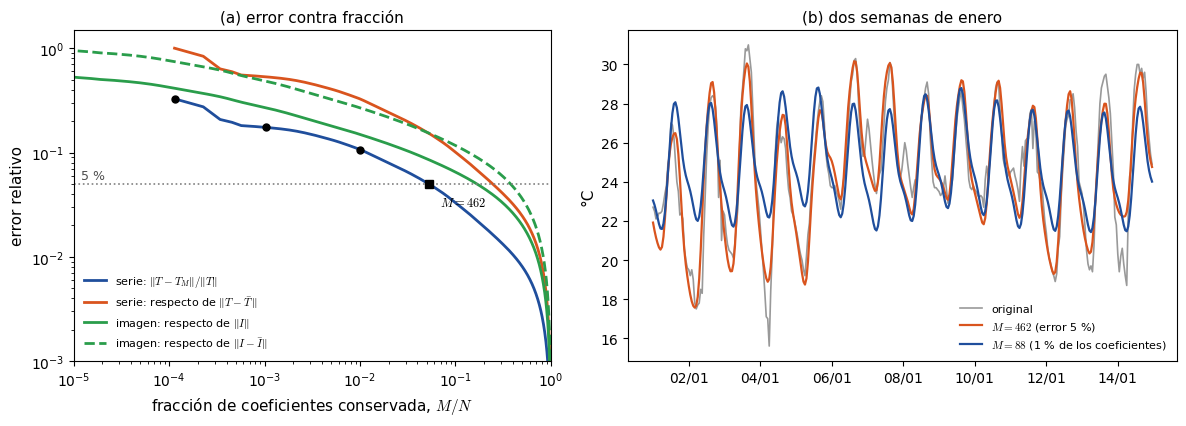

In [16]:
X = np.fft.fft(T)
orden = np.argsort(-np.abs(X))
E_ord = np.abs(X[orden]) ** 2 / N
resto = np.cumsum(E_ord[::-1])[::-1][1:]          # energía de los coeficientes descartados con M = 1, ..., N-1
err_rel = np.sqrt(resto) / np.linalg.norm(T)
err_fluct = np.sqrt(resto) / np.linalg.norm(T - T.mean())
Ms = np.arange(1, N)

def comprimir(M):
    Xm = np.zeros_like(X)
    Xm[orden[:M]] = X[orden[:M]]
    return np.fft.ifft(Xm).real

for M in (11, 101, 1001):
    e = np.linalg.norm(T - comprimir(M)) / np.linalg.norm(T)
    print(f"M = {M:4d}: error relativo {err_rel[M - 1]:.4f} (Plancherel) contra {e:.4f} (reconstruyendo)")
M_5 = int(Ms[np.argmax(err_rel <= 0.05)])
M_5_fluct = int(Ms[np.argmax(err_fluct <= 0.05)])
print(f"error 5 %: M = {M_5} ({100 * M_5 / N:.1f} % de N) respecto de ||T||;  M = {M_5_fluct} ({100 * M_5_fluct / N:.1f} %) respecto de ||T - media||")
for f in (0.01, 0.001, 0.0001):
    M = max(1, int(round(f * N)))
    print(f"fracción {100 * f:g} % -> M = {M:3d}: error {err_rel[M - 1]:.3f} (de ||T||), {err_fluct[M - 1]:.3f} (de las fluctuaciones)")
print("primeros índices k (<= N/2) por módulo:", [int(k) for k in orden[:40] if k <= N // 2][:20])
print("... con frecuencias xi (ciclos/día):", [round(float(k) / 365, 3) for k in orden[:40] if k <= N // 2][:12])
e_picos = np.sqrt(np.sum(E_ord[11:])) / np.linalg.norm(T)
print(f"solo la media y los 5 picos (11 coeficientes): error {e_picos:.3f} de ||T||, {np.sqrt(np.sum(E_ord[11:])) / np.linalg.norm(T - T.mean()):.3f} de las fluctuaciones")

img = plt.imread(datos.obtener("astronauta.png"))
if img.ndim == 3:
    img = img[..., 0]
Xi = np.fft.fft2(img)
Ei = np.sort(np.abs(Xi).ravel())[::-1] ** 2
resto_i = np.cumsum(Ei[::-1])[::-1][1:]
err_img = np.sqrt(resto_i / Ei.sum())
frac_i = np.arange(1, Ei.size) / Ei.size
dc_i = np.abs(Xi[0, 0]) ** 2
err_img_fl = np.sqrt(resto_i / (Ei.sum() - dc_i))         # respecto de las fluctuaciones de la imagen (sin la media)
print(f"imagen {img.shape}: error con el 1 %: {err_img[int(0.01 * Ei.size) - 1]:.3f}; 5 %: {err_img[int(0.05 * Ei.size) - 1]:.3f}; 0.1 %: {err_img[int(0.001 * Ei.size) - 1]:.3f}; "
      f"error del 5 % con {int(np.argmax(err_img <= 0.05)) + 1} coeficientes ({100 * (np.argmax(err_img <= 0.05) + 1) / Ei.size:.1f} %)")
print(f"respecto de las fluctuaciones (sin la media): serie {err_fluct[87]:.3f} (1 %) y {err_fluct[8]:.3f} (0.1 %); "
      f"imagen {err_img_fl[int(0.01 * Ei.size) - 1]:.3f} (1 %) y {err_img_fl[int(0.001 * Ei.size) - 1]:.3f} (0.1 %)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1, 1.15]})
ax1.loglog(Ms / N, err_rel, color=COLORES["dato"], lw=2, label=r"serie: $\|T - T_M\|/\|T\|$")
ax1.loglog(Ms / N, err_fluct, color=COLORES["modelo"], lw=2, label=r"serie: respecto de $\|T - \bar T\|$")
ax1.loglog(frac_i, err_img, color=CICLO[2], lw=2, label=r"imagen: respecto de $\|I\|$")
ax1.loglog(frac_i, err_img_fl, "--", color=CICLO[2], lw=2, label=r"imagen: respecto de $\|I - \bar I\|$")
for f in (0.01, 0.001, 0.0001):
    M = max(1, int(round(f * N)))
    ax1.plot(M / N, err_rel[M - 1], "o", color="black", ms=5, zorder=5)
ax1.axhline(0.05, color="0.5", ls=":", lw=1.2); ax1.text(1.2e-5, 0.056, "5 %", fontsize=9, color="0.3")
ax1.plot(M_5 / N, 0.05, "s", color="black", ms=6, zorder=5); ax1.annotate(f"$M = {M_5}$", (M_5 / N, 0.05), (8, -16), textcoords="offset points", fontsize=9)
ax1.set_xlabel("fracción de coeficientes conservada, $M/N$"); ax1.set_ylabel("error relativo"); ax1.set_xlim(1e-5, 1); ax1.set_ylim(1e-3, 1.5)
ax1.legend(loc="lower left", fontsize=8); ax1.set_title("(a) error contra fracción")
dos = ((fecha >= "2023-01-01") & (fecha < "2023-01-15")).values
ax2.plot(fecha[dos], T[dos], color="0.6", lw=1.2, label="original")
ax2.plot(fecha[dos], comprimir(M_5)[dos], color=COLORES["modelo"], lw=1.6, label=f"$M = {M_5}$ (error 5 %)")
ax2.plot(fecha[dos], comprimir(88)[dos], color=COLORES["dato"], lw=1.6, label="$M = 88$ (1 % de los coeficientes)")
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2)); ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax2.set_ylabel("°C"); ax2.legend(loc="lower right", fontsize=8); ax2.set_title("(b) dos semanas de enero")
fig.tight_layout()

In [17]:
# Verificación
assert abs(err_rel[100] - np.linalg.norm(T - comprimir(101)) / np.linalg.norm(T)) < 1e-6, "Plancherel debe coincidir con la reconstrucción"
assert 440 <= M_5 <= 480, "para el 5 % respecto de ||T|| hacen falta ~460 coeficientes"
assert M_5_fluct > 3 * M_5, "respecto de las fluctuaciones hacen falta muchos más"
assert abs(err_rel[87] - 0.107) < 0.01 and abs(err_rel[0] - 0.327) < 0.01, "1 % (M = 88): ~0.107; M = 1: ~0.327"
print("compresión: OK")

compresión: OK


**Para el docente (Tarea 8).** Con $M = 11, 101, 1001$ los errores por Plancherel son 0.1712, 0.1008 y 0.0299 y coinciden con la reconstrucción explícita. Con la fracción del 1 % ($M = 88$): 0.107 de $\|T\|$ (0.326 de las fluctuaciones); 0.1 % ($M = 9$): 0.174 (0.532); 0.01 % ($M = 1$, la media): 0.327 (1.000). Para 5 %: $M = 462$ ($5.3$ % de $N$) respecto de $\|T\|$, $M = 2150$ ($24.5$ %) respecto de las fluctuaciones. Los primeros coeficientes por módulo son $k = 0$ (media), 1 (anual), 365 (diario) y después **fluctuaciones de baja frecuencia** ($k = 25, 10, 20, 6, 5$, períodos de 15 a 70 días), recién en el noveno lugar el de 12 h ($k = 730$): la parte irregular, con energía repartida, se lleva muchos coeficientes. Solo la media y los cinco picos (11 coeficientes) dan un error de 0.171 (0.523 de las fluctuaciones). Imagen ($512\times512$): 1 %: 0.149 de $\|I\|$, 0.268 de las fluctuaciones; 5 %: 0.087; 0.1 %: 0.271 (0.487); el 5 % de error necesita el 16.8 % de los coeficientes. Es decir, respecto de la norma total la serie es más compresible (10.7 % contra 14.9 % con el 1 %); respecto de las fluctuaciones la imagen lo es un poco más (26.8 % contra 32.6 %): la serie tiene una media enorme, que gana con un solo número. La conclusión honesta: la serie se resume en 11 números que explican el 71 % de la varianza (y llevan el error a 17 %), y ningún truco de Fourier comprime bien la parte irregular. Errores típicos: ordenar `np.abs(X)` ascendente, olvidar la parte real, dividir por $N$ de menos al calcular energías con Plancherel (`|X|**2 / N`, no `/ N**2`). Tiempo: 40 minutos.

## 9. Espectrograma: cuando el contenido de frecuencias cambia

Un único espectro promedia sobre todo el registro: si la amplitud del ciclo diario cambia con la estación, o si una nota musical decae mientras suena, esa información está en el espectro pero *mezclada* (está en las fases de los coeficientes de la banda). El **espectrograma** o transformada de Fourier de tiempo corto (STFT) la muestra: se parte la señal en tramos de $N_v$ muestras (ventanas), separados por un **paso** de $p$ muestras, se calcula el periodograma de cada tramo (con una ventana de Hann para controlar la fuga) y se grafica la matriz $S[k, j]$ (potencia en la frecuencia $\xi_k$ del tramo $j$) como una imagen: tiempo en el eje horizontal (el del centro del tramo), frecuencia en el vertical y potencia en color, casi siempre en **escala logarítmica** (decibeles, $10\log_{10}S$).

### Los parámetros y el compromiso tiempo–frecuencia

* **Ventana** de duración $\tau = N_v\Delta t$: da la **resolución en frecuencia** $\Delta\xi = 1/\tau$ (Sección 1: es $1/T$ del tramo) y la **resolución temporal**: un cambio que dure menos que $\tau$ no se resuelve.
* Vale siempre $\Delta t_{\rm res}\cdot\Delta\xi \gtrsim 1$: **no se puede tener las dos resoluciones a la vez** (es el principio de incertidumbre de Fourier: una señal corta en el tiempo tiene un espectro ancho). Ventanas cortas, buena resolución temporal y espectro borroso; ventanas largas, picos finos pero las variaciones rápidas se promedian. No hay una ventana "correcta": depende de qué se quiere ver, y por eso es útil probar varias.
* **Solapamiento**: pasos $p < N_v$ (típico $p = N_v/2$, solapamiento del 50 %) evitan que un evento caiga en el borde de las ventanas, donde Hann lo atenúa. Solapar más da una imagen más suave pero no información nueva.

### Amplitud a partir de un espectrograma

Con Hann, un coseno de amplitud $A$ en la grilla da $|\hat{(xw)}[k]| = A\sum w/2$ y, con la normalización de `imc.espectro`, $S = |\hat{(xw)}|^2/\sum w^2$. Entonces $A = 2\sqrt{S\sum w^2}/\sum w$. Eso permite leer amplitudes en °C de la imagen, y compararlas con las que da un ajuste por mínimos cuadrados en cada ventana (el estimador "fuerte" de la Sección 3).

### La guitarra

`cuerda_guitarra.wav` (ver `datos/README.md`) es una cuerda de guitarra pulsada, mono a 44.1 kHz, 6 s. El **audio** cambia con el tiempo: una nota musical no es una frecuencia sino una **fundamental** más **armónicos** (múltiplos enteros: $2f_0, 3f_0, \dots$) cuyas amplitudes relativas definen el timbre, y que **decaen a distintas velocidades**. El enunciado de las notas habla de "una escala tocada en un instrumento y grabada con el teléfono", para identificar las notas; acá usamos la cuerda del repositorio, que no cambia de nota pero sí de amplitud y de contenido: es una buena razón para el espectrograma. El nombre de la nota sale de la frecuencia con la escala temperada: la nota MIDI es $n = 69 + 12\log_2(f/440)$ (La4 = 440 Hz = 69; los enteros son notas; cada 12 son una octava).

### Tarea 9: El espectrograma: temperatura y guitarra

1. **Implementación simple.** Escribí `espectrograma_simple(x, dt, tramo, paso)` que devuelve `(t_centros, xi, S)` con `S[k, j]` = periodograma del tramo $j$ con ventana de Hann, restando la media del tramo y con la normalización $|\hat{(xw)}[k]|^2/(N_v\,\overline{w^2})$ (la de `espectro.periodograma`). Comprobá que coincide con `espectro.espectrograma(x, dt, tramo, solapamiento=1 - paso/tramo)` para la temperatura (guardá el resultado propio como `ts, xi_s, S`).
2. **Temperatura.** Usá la serie de los tres años (`df.temp.values`) con ventanas de 30 días (720 horas) y paso de 15 días (360). Graficá el espectrograma con `pcolormesh` (fechas en el eje horizontal, $\xi \in [0, 4]$ ciclos/día en el vertical, potencia en $\log_{10}$). Calculá, para cada ventana, la amplitud del ciclo diario de dos maneras: (a) la que se lee de la fila $\xi = 1$ del espectrograma con $A = 2\sqrt{S\sum w^2}/\sum w$, y (b) por mínimos cuadrados con $\xi = 1$ fijo (`ajuste_ls` de la Tarea 3) en el tramo. Guardalas en `A_esp` y `A_min` y graficá las dos curvas contra la fecha. ¿En qué época del año es máxima la amplitud del ciclo diario y en cuál mínima? ¿Es el mismo patrón los tres años?
3. **Guitarra.** Cargá `datos.obtener("cuerda_guitarra.wav")` con `wavfile.read`, pasala a `float` y normalizala por 32768. Calculá el espectrograma con ventanas de 5 ms, 50 ms y 500 ms (paso = mitad de la ventana) y graficá los tres en dB (`10*np.log10(S + 1e-12)`, con un rango dinámico de unos 60–70 dB) para $\xi \in [0, 2000]$ Hz, con las ventanas de 5 ms, 50 ms y 500 ms en paneles vecinos.
4. **La nota y sus armónicos.** Con el periodograma con Hann de los primeros 3 s (`espectro.periodograma`), encontrá la frecuencia fundamental `f0` en Hz (el máximo en $[100, 400]$ Hz), decí de qué nota se trata (MIDI y nombre) y qué tan desafinada está (en *cents*: $1200\log_2(f_0/f_{\rm nota})$). Después, con el espectrograma de 50 ms, seguí la evolución temporal de la fundamental y de sus primeros cuatro armónicos (la potencia máxima en $\pm 20$ Hz de $m f_0$) y estimá para cada uno su velocidad de decaimiento en dB/s entre $t = 0.2$ y $2.5$ s (recta de mínimos cuadrados en dB). Guardá `decaimiento` (arreglo de 5, en dB/s, negativos).
5. **Compromiso.** Con los tres espectrogramas de (3): ¿qué se ve y qué no se ve con 5 ms? ¿Y con 500 ms? ¿Cuánto vale $\Delta\xi$ para cada ventana y cómo se compara con la separación entre armónicos ($f_0 \approx 196$ Hz)? Lo mismo con la temperatura: ¿qué pasaría con una ventana de 3 días? ¿Y de 1 año?

**Qué se espera.** En la temperatura: una raya horizontal brillante en $\xi = 1$ (y otra más débil en $\xi = 2$) cuyo brillo sube y baja con las estaciones; las amplitudes de (a) y (b) siguen el mismo patrón general pero no coinciden (diferencias de hasta medio grado en algunas ventanas): son estimadores distintos, porque Hann pondera el centro de la ventana de 30 días y descarta casi por completo los bordes, mientras que mínimos cuadrados usa todo el tramo con el mismo peso. En la guitarra: una fundamental en $\approx 196$ Hz (Sol$_3$) con armónicos en $\approx 392, 588, 784, \dots$ Hz que decaen a velocidades distintas (los agudos más rápido); con 5 ms ($\Delta\xi = 200$ Hz) los armónicos se funden en una sola mancha; con 500 ms ($\Delta\xi = 2$ Hz) cada armónico es una raya finita pero el ataque (el pulsado) se "difumina" en el tiempo; con 50 ms ($\Delta\xi = 20$ Hz) se ve el mejor compromiso.

S: (361, 72) (frecuencias × ventanas); resolución 0.0333 ciclos/día; diferencia con imc.espectro.espectrograma: 0.0e+00
amplitud diaria por ventana: espectrograma 1.82–4.15 °C, mínimos cuadrados 1.93–3.55 °C; correlación entre ambas 0.883
       verano (dic–feb): amplitud diaria media 2.90 °C
        otoño (mar–may): amplitud diaria media 2.46 °C
     invierno (jun–ago): amplitud diaria media 2.44 °C
    primavera (sep–nov): amplitud diaria media 3.02 °C


fundamental f0 = 195.73 Hz -> nota MIDI 54.98 ~ 55: Sol3 (196.00 Hz), desafinada -2.3 cents
   armónico 1:   196.0 Hz (m f0 =   195.7, cociente 1.0014);  decae  -12.5 dB/s
   armónico 2:   392.0 Hz (m f0 =   391.5, cociente 1.0014);  decae  -12.2 dB/s
   armónico 3:   588.7 Hz (m f0 =   587.2, cociente 1.0025);  decae  -18.2 dB/s
   armónico 4:   784.7 Hz (m f0 =   782.9, cociente 1.0022);  decae  -19.6 dB/s
   armónico 5:   982.0 Hz (m f0 =   978.7, cociente 1.0034);  decae  -16.7 dB/s


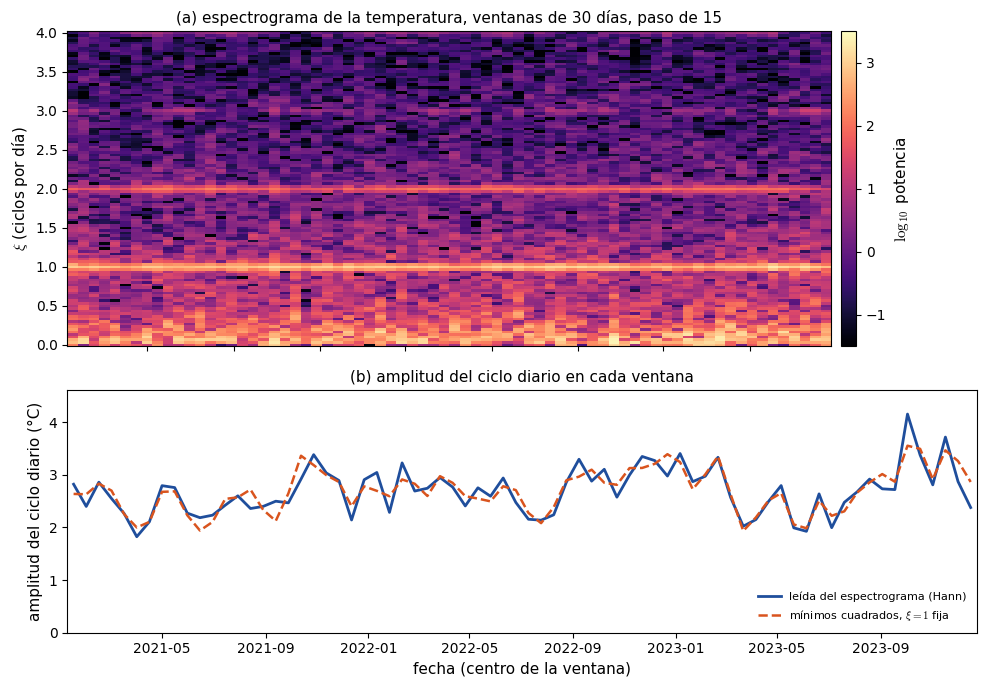

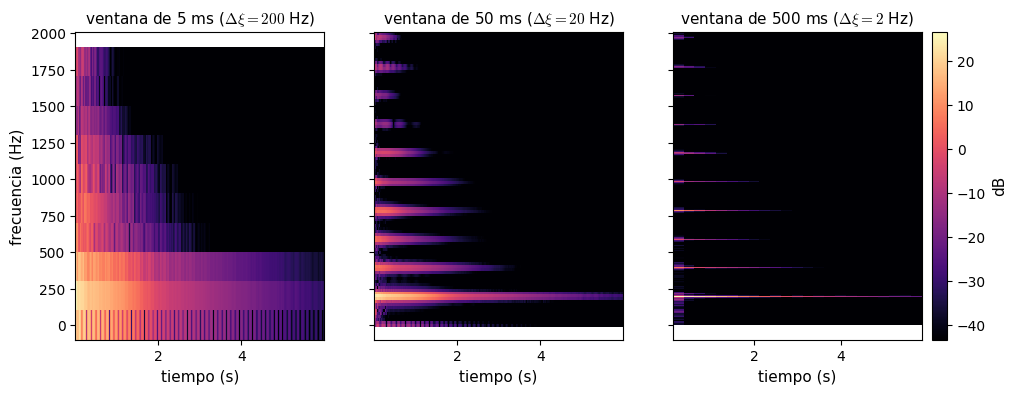

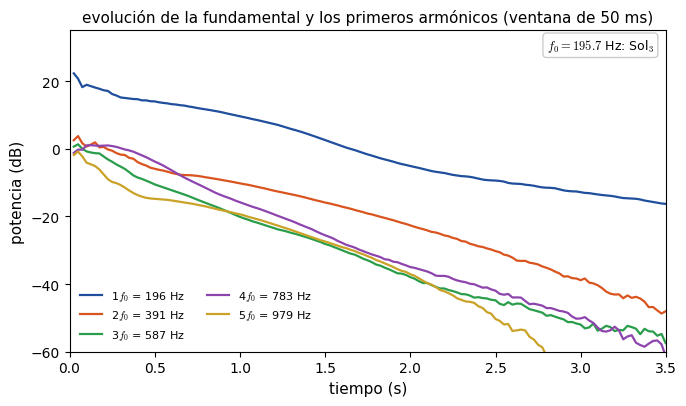

In [18]:
def espectrograma_simple(x, dt, tramo, paso):
    x = np.asarray(x, float)
    w = np.hanning(tramo)
    xi = np.fft.rfftfreq(tramo, d=dt)
    ts, cols = [], []
    for i in range(0, len(x) - tramo + 1, paso):
        seg = x[i:i + tramo]
        Xs = np.fft.rfft((seg - seg.mean()) * w)
        cols.append(np.abs(Xs) ** 2 / (tramo * np.mean(w ** 2)))
        ts.append((i + tramo / 2) * dt)
    return np.array(ts), xi, np.array(cols).T

T3 = df.temp.values
tramo, paso = 720, 360
ts, xi_s, S = espectrograma_simple(T3, dt, tramo, paso)
ts_i, xi_i, S_i = espectro.espectrograma(T3, dt, tramo, solapamiento=1 - paso / tramo)
print(f"S: {S.shape} (frecuencias × ventanas); resolución {xi_s[1]:.4f} ciclos/día; diferencia con imc.espectro.espectrograma: {np.abs(S - S_i).max():.1e}")

fechas_v = df.fecha_hora.iloc[0] + pd.to_timedelta(ts, unit="D")
w = np.hanning(tramo)
k1 = np.argmin(abs(xi_s - 1))
A_esp = 2 * np.sqrt(S[k1] * np.sum(w ** 2)) / np.sum(w)
A_min = np.array([ajuste_ls(T3[i:i + tramo], np.arange(tramo) * dt, [1.0])[1][0] for i in range(0, len(T3) - tramo + 1, paso)])
print(f"amplitud diaria por ventana: espectrograma {A_esp.min():.2f}–{A_esp.max():.2f} °C, mínimos cuadrados {A_min.min():.2f}–{A_min.max():.2f} °C; "
      f"correlación entre ambas {np.corrcoef(A_esp, A_min)[0, 1]:.3f}")
mes_v = fechas_v.month
for nombre, ms in [("verano (dic–feb)", [12, 1, 2]), ("otoño (mar–may)", [3, 4, 5]), ("invierno (jun–ago)", [6, 7, 8]), ("primavera (sep–nov)", [9, 10, 11])]:
    print(f"   {nombre:>20s}: amplitud diaria media {A_min[np.isin(mes_v, ms)].mean():.2f} °C")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})
m = xi_s <= 4
im = ax1.pcolormesh(fechas_v, xi_s[m], np.log10(S[m] + 1e-9), shading="nearest", cmap="magma", vmin=-1.5, vmax=3.5)
fig.colorbar(im, ax=ax1, label=r"$\log_{10}$ potencia", pad=0.01)
ax1.set_ylabel(r"$\xi$ (ciclos por día)"); ax1.set_title("(a) espectrograma de la temperatura, ventanas de 30 días, paso de 15")
ax2.plot(fechas_v, A_esp, color=COLORES["dato"], lw=2, label="leída del espectrograma (Hann)")
ax2.plot(fechas_v, A_min, "--", color=COLORES["modelo"], lw=1.8, label="mínimos cuadrados, $\\xi = 1$ fija")
ax2.set_ylabel("amplitud del ciclo diario (°C)"); ax2.legend(loc="lower right", fontsize=8); ax2.set_title("(b) amplitud del ciclo diario en cada ventana")
ax2.set_ylim(0, 4.6); ax2.set_xlabel("fecha (centro de la ventana)")
fig.tight_layout()
figura_espectro_T = fig

sr, audio = wavfile.read(datos.obtener("cuerda_guitarra.wav"))
audio = audio.astype(float) / 32768
dt_a = 1 / sr
def espec_audio(dur):
    tr = int(dur * sr)
    return espectrograma_simple(audio, dt_a, tr, tr // 2)
resultados = {dur: espec_audio(dur) for dur in (0.005, 0.05, 0.5)}
fig, axs = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (dur, (tg, xg, Sg)) in zip(axs, resultados.items()):
    mm = xg <= 2000
    dB = 10 * np.log10(Sg[mm] + 1e-12)
    im = ax.pcolormesh(tg, xg[mm], dB, shading="nearest", cmap="magma", vmin=dB.max() - 70, vmax=dB.max())
    ax.set_title(f"ventana de {1000 * dur:g} ms ($\\Delta\\xi = {1 / dur:g}$ Hz)"); ax.set_xlabel("tiempo (s)")
axs[0].set_ylabel("frecuencia (Hz)")
fig.colorbar(im, ax=axs, label="dB", pad=0.01)
figura_guitarra = fig

xa, Pa = espectro.periodograma(audio[:3 * sr], dt_a, ventana="hann")
ban = (xa > 100) & (xa < 400)
i0 = np.argmax(np.where(ban, Pa, 0))
y0, y1, y2 = np.log(Pa[i0 - 1:i0 + 2])
f0 = xa[i0] + 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2) * (xa[1] - xa[0])         # interpolación parabólica
nota_midi = 69 + 12 * np.log2(f0 / 440)
n_red = int(round(nota_midi))
nombres = ["Do", "Do#", "Re", "Re#", "Mi", "Fa", "Fa#", "Sol", "Sol#", "La", "La#", "Si"]
f_nota = 440 * 2 ** ((n_red - 69) / 12)
cents = 1200 * np.log2(f0 / f_nota)
print(f"fundamental f0 = {f0:.2f} Hz -> nota MIDI {nota_midi:.2f} ~ {n_red}: {nombres[n_red % 12]}{n_red // 12 - 1} ({f_nota:.2f} Hz), desafinada {cents:+.1f} cents")

tg, xg, Sg = resultados[0.05]
dB50 = 10 * np.log10(Sg + 1e-12)
def fila(f, ancho=20):
    return dB50[np.abs(xg - f) <= ancho].max(axis=0)
ms_arm = np.arange(1, 6)
mm_t = (tg > 0.2) & (tg < 2.5)
decaimiento = np.array([np.polyfit(tg[mm_t], fila(m * f0)[mm_t], 1)[0] for m in ms_arm])
# frecuencias de los armónicos medidas en el periodograma de los primeros 1.5 s (¿son exactamente m f0?)
x15, P15 = espectro.periodograma(audio[:int(1.5 * sr)], dt_a, ventana="hann")
frec_arm = np.array([x15[np.abs(x15 - m * f0) < 15][np.argmax(P15[np.abs(x15 - m * f0) < 15])] for m in ms_arm])
for m, fr, dk in zip(ms_arm, frec_arm, decaimiento):
    print(f"   armónico {m}: {fr:7.1f} Hz (m f0 = {m * f0:7.1f}, cociente {fr / (m * f0):.4f});  decae {dk:6.1f} dB/s")

fig, ax = plt.subplots(figsize=(7, 4.2))
for m, c in zip(ms_arm, CICLO):
    ax.plot(tg, fila(m * f0), color=c, label=f"{m}$f_0$ = {m * f0:.0f} Hz")
ax.set_xlim(0, 3.5); ax.set_ylim(-60, 35); ax.set_xlabel("tiempo (s)"); ax.set_ylabel("potencia (dB)")
ax.legend(fontsize=8, ncol=2); ax.set_title("evolución de la fundamental y los primeros armónicos (ventana de 50 ms)")
estilo.parametros(ax, f"$f_0 = {f0:.1f}$ Hz: {nombres[n_red % 12]}$_{{{n_red // 12 - 1}}}$", loc="upper right")
fig.tight_layout()
figura_armonicos = fig

In [19]:
# Verificación
_, _, S_imc = espectro.espectrograma(df.temp.values, dt, 720, solapamiento=0.5)
assert np.allclose(S, S_imc, rtol=1e-8, atol=1e-10), "tu espectrograma debe coincidir con el de imc (resta de la media, Hann de np.hanning, |X|^2 / (N mean(w^2)))"
assert np.corrcoef(A_esp, A_min)[0, 1] > 0.75, "las dos amplitudes diarias deben tener el mismo patrón general"
assert 194 < f0 < 198 and round(69 + 12 * np.log2(f0 / 440)) == 55, "la fundamental es ~196 Hz: Sol3 (MIDI 55)"
assert np.all(decaimiento < -5) and decaimiento[3] < decaimiento[0], "todos decaen, los agudos más rápido que la fundamental"
print("espectrogramas: OK")

espectrogramas: OK


**Para el docente (Tarea 9).** Espectrograma de tres años ($S$ de $361 \times 72$, $\Delta\xi = 1/30$): difiere de `imc.espectro.espectrograma` en $0$. Amplitud diaria por ventana: 1.82–4.15 °C (espectrograma) y 1.93–3.55 °C (mínimos cuadrados), con correlación 0.88: no coinciden porque Hann pondera el centro de la ventana y descarta los bordes (y es bastante más ruidosa: un tramo efectivo de la mitad del largo). Medias de la amplitud por estación (mínimos cuadrados): verano 2.90 °C, otoño 2.46, invierno 2.44, primavera 3.02: el ciclo diario es más marcado en primavera y verano (más sol, cielos despejados) y menos en invierno; el patrón se repite los tres años con diferencias de $\pm 0.5$ °C ventana a ventana. **Guitarra:** $f_0 = 195.73$ Hz (con interpolación parabólica sobre el periodograma de los primeros 3 s): 196.0 Hz es Sol$_3$, MIDI 55; $-2.3$ cents, dentro de la incertidumbre de la estimación. Armónicos medidos en 196.0, 392.0, 588.7, 784.7 y 982.0 Hz: cocientes con $m f_0$ de 1.0014 a 1.0034, una leve inarmonicidad (las cuerdas reales tienen rigidez: los armónicos superiores son algo más agudos); decaimientos: $-12.5, -12.2, -18.2, -19.6, -16.7$ dB/s: los agudos decaen más rápido (por eso el sonido "se oscurece" al apagarse). Con 5 ms ($\Delta\xi = 200$ Hz $\approx f_0$) los armónicos no se separan; con 500 ms ($\Delta\xi = 2$ Hz) son rayas finas pero el ataque (la pulsación) queda promediado en medio segundo; con 50 ms ($\Delta\xi = 20$ Hz $\ll f_0$) se ven los armónicos separados y sus decaimientos. En la temperatura, una ventana de 3 días ($\Delta\xi = 0.33$) no puede separar el ciclo diario de la variabilidad sinóptica que lo rodea y de sus bandas laterales, y una de 1 año da otra vez el espectro global de la Tarea 2. Errores típicos: no dividir el wav por 32768 (no cambia las dB relativas, pero sí los valores absolutos), usar `sr` en lugar de `1/sr` como `dt`, `log10` de ceros. Tiempo: 60 minutos.

## Interpretación

Esta es la parte que se evalúa. Respondé en las celdas de texto que siguen, con oraciones completas y citando los números o gráficos que obtuviste.

**1.** **Frecuencias, amplitudes y fases.** ¿Qué frecuencias contiene la serie de temperatura? Da una tabla o una lista con las amplitudes (°C), las fechas u horas de los máximos y la fracción de la varianza que explica cada componente (Tareas 2 a 4). ¿Cuánto de la variabilidad total explican los ciclos diario y anual, con sus armónicos, y qué significa ese número? Explicá por qué la amplitud del ciclo diario no es una constante sino que cambia con la estación (Tareas 3 y 9) y por qué al estimarla en un tramo corto la DFT y el ajuste por mínimos cuadrados pueden dar valores distintos y cuál conviene.

**2.** **La parte regular y lo que queda.** Describí cómo separaste la temperatura regular del residuo (Tarea 7) y qué queda: ¿es ruido blanco? Fundamentá con el espectro, la autocorrelación y las escalas de tiempo de mayor energía; asociá esas escalas con algo físico. Comparalo con el promedio móvil de 24 h y con el de 7 días: explicá con la respuesta en frecuencia (ceros, lóbulos) qué borra exactamente cada uno y en qué es peor que el filtro de picos. Además: ¿qué efecto tiene la fuga espectral y la ventana de Hann sobre la lectura del espectro entre los picos (Tarea 5)?

**3.** **Muestrear menos.** Si en lugar de una medición por hora hubiera una por día, o una por semana: ¿qué información se pierde y cuál se falsea? Explicalo con tus resultados de la Tarea 6: a dónde fue el ciclo diario, cuánto cambió la media, por qué depende de la hora elegida, y qué pasa cuando el intervalo de muestreo no divide al día (los 25 h). Formulá una regla práctica (con la frecuencia de Nyquist) para decidir cada cuánto hay que medir para no falsear el ciclo diario.

**4.** **Cuántos números y qué se pierde.** ¿Cuántos coeficientes hacen falta para reconstruir la serie con un error del 5 %? Distinguí el error respecto de la norma de la señal y respecto de las fluctuaciones (Tarea 8) y decí cuál es más honesto. Comparalo con la imagen. Escribí el párrafo de conclusión que pide el ejercicio de las notas: qué información contiene esta serie, en cuántos números se la puede resumir y qué se pierde al hacerlo.

**5.** **¿Sirven las mismas herramientas para otras señales?** Con lo que hiciste con la guitarra (Tarea 9), la imagen (Tarea 8) y la temperatura: ¿qué herramienta sirvió igual para las tres y cuál no? ¿Qué cambia cuando la señal deja de ser estacionaria (el contenido de frecuencias cambia con el tiempo) y cómo lo resuelve el espectrograma, a qué costo? ¿Qué elegirías para un electrocardiograma (una señal casi periódica con un latido de forma fija, que cambia de ritmo) y por qué?

### Respuestas modelo (para el docente)

**1. Frecuencias, amplitudes y fases.** La serie tiene un ciclo anual ($\xi = 1/365$ ciclos/día, $A = 6.9$ °C, máximo el 25 de enero) y un ciclo diario ($\xi = 1$, $A = 2.8$ °C, máximo a las 15:45) y sus armónicos (12 h con $A = 0.83$ °C, 8 h con 0.07 °C, 6 h con 0.13 °C), más un piso continuo con potencia $\propto \xi^{-2}$. El semianual ($A = 0.8$ °C) no se distingue de las fluctuaciones vecinas. Por Parseval, el ciclo anual explica el 59.9 % de la varianza, el diario el 9.5 % y con los armónicos y el semianual el conjunto llega al 71.0 %: casi el 30 % restante es variabilidad irregular (frentes). Que un ciclo explique el 60 % significa que el modelo $c + A\cos(2\pi t/365 + \varphi)$ tiene $R^2 = 0.6$ sobre los datos horarios. La amplitud del ciclo diario cambia con la estación (enero 3.0 °C, julio 2.3 °C; por ventanas de 30 días entre 1.9 y 3.5 °C) porque depende de la insolación y de la nubosidad y, en el espectro global, esa modulación se ve como "hombros" alrededor de $\xi = 1$ (frecuencias $1 \pm 1/365$). En un tramo corto, la DFT solo puede mirar frecuencias de una grilla de paso $1/T$: si $\xi = 1$ queda entre dos coeficientes, subestima la amplitud (10.5 días: 2.0 °C contra 3.1 °C); mínimos cuadrados con la frecuencia conocida no depende de la grilla y conviene (siempre que la frecuencia sea conocida, como acá).

**2. La parte regular y lo que queda.** Se filtra en frecuencia conservando la media y los picos ($k = 1, 2, 365, 730, 1095$) y se antitransforma; queda un residuo de desvío 3.4 °C. No es ruido blanco: su espectro baja cuatro órdenes de magnitud entre $\xi \approx 0.03$ y $\xi \approx 7$ ciclos/día, con pendiente $-2$ en log-log; la autocorrelación a 1 h es 0.98 y a 24 h todavía 0.58; el 70 % de la energía está en períodos de 2 a 30 días: el paso de frentes y masas de aire (escala sinóptica, de 3 a 10 días) y las anomalías de varias semanas. El promedio móvil de 24 h tiene respuesta $|\sin(\pi\xi)/(24\sin(\pi\xi/24))| \approx |{\rm sinc}(\xi\cdot 1\,\text{día})|$ con ceros exactos en $1, 2, 3, \dots$ ciclos/día: borra el ciclo diario y todos sus armónicos sin haber elegido frecuencias; el de 7 días tiene ceros en múltiplos de $1/7$ y, además, atenúa todo lo que dura menos de una semana. Son peores que el filtro de picos en que dejan pasar lóbulos laterales (21 % de $\xi = 1.5$) y atenúan lo que se quiere conservar, y hacen *lo opuesto*: tiran el ciclo diario, mientras que el filtro de picos se queda con él. Sobre la fuga espectral y la ventana de Hann: el piso entre los picos es un piso de ruido rojo, y con Hann cambia poco (entre 10 y 30 % menor); donde la fuga sí importa es en un tramo que no contiene un número entero de períodos y para leer amplitudes (control: 0.65 con rectangular y 0.85 con Hann, contra 1), y la ventana lo paga con un pico más ancho (resolución a la mitad).

**3. Muestrear menos.** Con una medición por día se pierde todo lo que ocurre dentro del día (el ciclo diario ya no existe como oscilación) y se *falsea* la media: el ciclo diario se pliega sobre $\xi = 0$ y la media de las 15 h es 21.5 °C contra 18.2 °C (sesgo $+3.3$ °C, que es el valor a las 15 h del ciclo diario completo; a las 3 h es $-2.1$ °C y a las 9 h $-1.1$ °C). Es un sesgo sistemático, no ruido, y no hay forma de detectarlo mirando solo la serie submuestreada. El ciclo anual sobrevive intacto (6.9 °C) porque una muestra por día cumple Nyquist para él. Con una por semana ocurre lo mismo (7 días es múltiplo de 24 h). Si el intervalo no divide al día, el ciclo diario aparece como una oscilación falsa: con 25 h se pliega en $|1 - 0.96| = 0.04$ ciclos/día (25 días), con amplitud del orden de 2 °C, un ciclo que no existe. Regla: para no falsear una componente de frecuencia $\xi$ hay que muestrear a más de $2\xi$ (Nyquist); para el ciclo diario, más seguido que cada 12 h (y mejor cada pocas horas, para sus armónicos). Si hay que submuestrear, se promedia antes (un promedio de 24 h elimina el ciclo diario en lugar de pegarlo sobre la media).

**4. Cuántos números y qué se pierde.** Con los 11 coeficientes de la media y los picos, el error relativo es 17 % (52 % de las fluctuaciones); para un 5 % de error respecto de $\|T\|$ hacen falta 462 coeficientes (5.3 % de las 8760 muestras); para un 5 % de las fluctuaciones, 2150 (un cuarto). Es más honesto el error respecto de las fluctuaciones (con la media sola ya se tiene 33 % de error respecto de $\|T\|$). Comparada con la imagen (5 % de error con el 17 % de los coeficientes), la serie parece más comprimible, pero solo por la media; respecto de las fluctuaciones son comparables (33 % y 27 % con el 1 %). Conclusión: la serie contiene una media (18.2 °C), dos ciclos (anual y diario; alcanza con la amplitud y la fase de cada uno, más algunos armónicos) que explican el 71 % de la varianza, y una parte irregular con memoria de días a semanas y espectro $\xi^{-2}$ que no se comprime: el 29 % restante son los frentes, que no son periódicos y en Fourier ocupan muchos coeficientes. Con 11 números se reconstruye el año "típico"; al hacerlo se pierden las olas de calor y de frío, los frentes y cualquier evento, es decir, justamente lo que interesa para pronosticar.

**5. Otras señales.** La DFT, el periodograma, el filtrado y la compresión sirven para las tres señales, con cuidados distintos. En la guitarra, el espectro global mezcla toda la duración y hace falta el espectrograma para ver que los armónicos decaen a distinta velocidad ($-12$ a $-20$ dB/s) y para identificar la nota (Sol$_3$, 196 Hz). En la imagen se usa la DFT bidimensional y la compresión funciona (5 % de error con el 17 % de los coeficientes), aunque el truncamiento espectral introduce ondulaciones (Gibbs) en los bordes. Lo que no sirve tal cual es el espectro global cuando la señal no es estacionaria (el contenido de frecuencias cambia con el tiempo: una nota que decae, el ciclo diario que cambia con la estación): ahí el espectrograma da la evolución, al costo del compromiso tiempo–frecuencia $\Delta t\,\Delta\xi \gtrsim 1$ (ventanas de 5 ms no separan armónicos a 196 Hz; las de 500 ms no resuelven el ataque). Un electrocardiograma es una señal casi periódica con un latido de forma fija y un ritmo que varía: el espectro muestra la frecuencia cardíaca y muchos armónicos (el latido no es sinusoidal); el espectrograma seguiría los cambios de ritmo; y como un latido es un evento localizado (el pico R es angosto), el análisis tiempo–frecuencia con ventanas o con wavelets es más natural que Fourier global (los transitorios agudos ensanchan el espectro).

**Tiempos.** Tareas 1–4: 2 h; Tarea 5: 35 min; Tarea 6: 25; Tarea 7: 60; Tarea 8: 40; Tarea 9: 60; interpretación: en casa (o una hora extra). Total en el laboratorio: entre 5 y 6 horas, así que se recomienda dividirlo en dos sesiones (Tareas 1–6 y 7–9). Si hay que recortar: se pueden saltar el ítem 4 de la Tarea 3 (tramo de 10.5 días), la parte real de la Tarea 5, o los promedios móviles de la Tarea 7 (pedir solo la respuesta en frecuencia).

### Cambios sugeridos para el texto de las notas (ejercicios de laboratorio de la Parte II)

* *Espectrograma, ítem 2:* reemplazar "una escala tocada en un instrumento, grabada con el teléfono" por el archivo `datos/cuerda_guitarra.wav` (cuerda de guitarra, Sol$_3$, 6 s, ver `datos/README.md`): identificar la nota y los armónicos y estimar su decaimiento. La escala grabada con el teléfono queda como extensión opcional para quien tenga un instrumento.
* *Espectro de la serie de temperatura, ítem 2:* la pregunta "¿aparece algún otro pico?" tiene como respuesta honesta que el semianual **no** se distingue de las fluctuaciones vecinas con un solo año (realce 2.3), y sí el armónico de 6 h (más alto que el de 8 h). Convendría sacar el ciclo semianual de la lista de picos (también en el notebook `08-aplicaciones`, que lo incluye) o aclarar que se lo conserva por convención.
* *Filtrado y compresión, ítem 3:* el número "cuántos coeficientes hacen falta para un error del 5 %" depende de la norma (respecto de $\|T\|$: 462; respecto de $\|T - \bar T\|$: 2150). Convendría precisar en el enunciado cuál se usa y pedir ambos: es una diferencia conceptual importante, y la comparación con la imagen cambia de signo según la norma.
* *Espectro de potencia:* el enunciado dice $|\hat u[k]|^2$; en el código (`imc.espectro.periodograma`) está normalizado por $N$ ($|\hat u[k]|^2/N$, para que valga Parseval); vale la pena unificar la convención.
* *Problema conductor, pregunta 3:* las notas mencionan una medición por semana; se cubre en la discusión (misma historia que la diaria porque 7 días es múltiplo de 24 h) y con el muestreo de 25 h como ejemplo de aliasing genuino, que no aparece en las notas.